<a href="https://colab.research.google.com/github/Oleksandr-Fedorov/Reaserch_diploma_work/blob/main/Full.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!unzip -q -j dataset.zip -d /content/dataset/

import torch
import os

if torch.cuda.is_available():
    print(f" GPU активований! Відеокарта: {torch.cuda.get_device_name(0)}")
else:
    print("Увага: це процесор!")

total_files = len([f for f in os.listdir('/content/dataset/') if f.endswith('.jpg')])
print(f"Знайдено ELA-рентгенів: {total_files}")

 GPU активований! Відеокарта: Tesla T4
Знайдено ELA-рентгенів: 1721


In [ ]:
torch.save(model.state_dict(), 'ela_cnn_baseline.pth')
print("🧠 Мозг нейросети успешно сохранен в файл ela_cnn_baseline.pth!")

🧠 Мозг нейросети успешно сохранен в файл ela_cnn_baseline.pth!


In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
from PIL import Image

# 1. Включаем видеокарту
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 2. Учим Питон понимать нашу разметку (REAL vs FAKE)
class ELADataset(Dataset):
    def __init__(self, folder_path, transform=None):
        self.folder_path = folder_path
        self.transform = transform
        self.image_files = [f for f in os.listdir(folder_path) if f.endswith('.jpg')]

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_name = self.image_files[idx]
        img_path = os.path.join(self.folder_path, img_name)

        # Открываем картинку
        image = Image.open(img_path).convert('RGB')

        # МАГИЯ РАЗМЕТКИ: Если имя начинается с FAKE - это подделка (класс 1)
        label = 1 if img_name.startswith("FAKE") else 0

        if self.transform:
            image = self.transform(image)

        return image, label

# 3. Подготавливаем картинки (сжимаем до 128x128 для скорости прототипа)
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(), # Превращаем пиксели в тензоры
])

# Загружаем датасет и динамически делим его: 80% на учебу, 20% на экзамен
dataset = ELADataset(folder_path='/content/dataset/', transform=transform)
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

# Создаем "погрузчики" данных (они будут кидать картинки в видеокарту пачками по 32 штуки)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"Всього фото: {len(dataset)}. Для навчання: {len(train_dataset)}, на екзамен: {len(test_dataset)}")

# 4. АРХИТЕКТУРА CNN (Тот самый мозг, который ищет аномалии)
class ELA_Scanner(nn.Module):
    def __init__(self):
        super(ELA_Scanner, self).__init__()
        # Сверточные слои (ищут признаки: края, шум, несовпадение блоков)
        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2), # Уменьшаем размер картинки в 2 раза

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        # Классификатор (принимает решение)
        self.fc_layers = nn.Sequential(
            nn.Linear(32 * 32 * 32, 128),
            nn.ReLU(),
            nn.Linear(128, 2) # Выдает 2 варианта: 0 (Оригинал) или 1 (Фейк)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = x.view(x.size(0), -1) # Вытягиваем тензор в линию
        x = self.fc_layers(x)
        return x

model = ELA_Scanner().to(device)

# 5. Настраиваем учителя (Функция потерь и оптимизатор Adam)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 6. ТРЕНИРОВКА (Запускаем на 10 циклов)
epochs = 10
print("\n--- ЕТАП НАВЧАННЯ (ELA-map) ---")
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Епоха {epoch+1}/{epochs} закінчена. Помилка (Loss): {running_loss/len(train_loader):.4f}")

# 7. ЭКЗАМЕН (Проверяем на 20% картинок, которые сеть никогда не видела)
model.eval()
correct = 0
total = 0
with torch.no_grad(): # Отключаем обучение
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f"\n ТОЧНІСТЬ МЕРЕЖІ НА ЭКЗАМЕНІ: {accuracy:.2f}%")
torch.save(model.state_dict(), 'model_ela_63ff.pth')
print("🧠 Веса ELA-модели сохранены в файл model_ela_63ff.pth")

Всього фото: 1721. Для навчання: 1376, на екзамен: 345

--- ЕТАП НАВЧАННЯ (ELA-map) ---
Епоха 1/10 закінчена. Помилка (Loss): 0.6484
Епоха 2/10 закінчена. Помилка (Loss): 0.6102
Епоха 3/10 закінчена. Помилка (Loss): 0.5878
Епоха 4/10 закінчена. Помилка (Loss): 0.5709
Епоха 5/10 закінчена. Помилка (Loss): 0.5591
Епоха 6/10 закінчена. Помилка (Loss): 0.5322
Епоха 7/10 закінчена. Помилка (Loss): 0.5147
Епоха 8/10 закінчена. Помилка (Loss): 0.4885
Епоха 9/10 закінчена. Помилка (Loss): 0.4567
Епоха 10/10 закінчена. Помилка (Loss): 0.4176

 ТОЧНІСТЬ МЕРЕЖІ НА ЭКЗАМЕНІ: 64.35%
🧠 Веса ELA-модели сохранены в файл model_ela_63ff.pth


In [ ]:
import os

real = len([f for f in os.listdir('/content/dataset/') if f.startswith('REAL')])
fake = len([f for f in os.listdir('/content/dataset/') if f.startswith('FAKE')])

print(f"✅ Оригиналов (REAL): {real}")
print(f"❌ Подделок (FAKE): {fake}")

✅ Оригиналов (REAL): 800
❌ Подделок (FAKE): 921


In [ ]:
!unzip -q -j raw_dataset.zip -d /content/raw_dataset/

import torch
import os

if torch.cuda.is_available():
    print(f"✅ GPU активирован! Видеокарта: {torch.cuda.get_device_name(0)}")
else:
    print("❌ Внимание: Работаем на процессоре!")

total_files = len([f for f in os.listdir('/content/raw_dataset/') if f.endswith('.jpg')])
print(f"📦 Найдено ELA-рентгенов: {total_files}")

✅ GPU активирован! Видеокарта: Tesla T4
📦 Найдено ELA-рентгенов: 1711


In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
from PIL import Image

# 1. Включаем видеокарту
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 2. Учим Питон понимать нашу разметку (REAL vs FAKE)
class ELADataset(Dataset):
    def __init__(self, folder_path, transform=None):
        self.folder_path = folder_path
        self.transform = transform
        self.image_files = [f for f in os.listdir(folder_path) if f.endswith('.jpg')]

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_name = self.image_files[idx]
        img_path = os.path.join(self.folder_path, img_name)

        # Открываем картинку
        image = Image.open(img_path).convert('RGB')

        # МАГИЯ РАЗМЕТКИ: Если имя начинается с FAKE - это подделка (класс 1)
        label = 1 if img_name.startswith("FAKE") else 0

        if self.transform:
            image = self.transform(image)

        return image, label

# 3. Подготавливаем картинки (сжимаем до 128x128 для скорости прототипа)
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(), # Превращаем пиксели в тензоры
])

# Загружаем датасет и динамически делим его: 80% на учебу, 20% на экзамен
dataset = ELADataset(folder_path='/content/raw_dataset/', transform=transform)
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

# Создаем "погрузчики" данных (они будут кидать картинки в видеокарту пачками по 32 штуки)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"Всього фото: {len(dataset)}. Для навчання: {len(train_dataset)}, на екзамен: {len(test_dataset)}")

# 4. АРХИТЕКТУРА CNN (Тот самый мозг, который ищет аномалии)
class ELA_Scanner(nn.Module):
    def __init__(self):
        super(ELA_Scanner, self).__init__()
        # Сверточные слои (ищут признаки: края, шум, несовпадение блоков)
        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2), # Уменьшаем размер картинки в 2 раза

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        # Классификатор (принимает решение)
        self.fc_layers = nn.Sequential(
            nn.Linear(32 * 32 * 32, 128),
            nn.ReLU(),
            nn.Linear(128, 2) # Выдает 2 варианта: 0 (Оригинал) или 1 (Фейк)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = x.view(x.size(0), -1) # Вытягиваем тензор в линию
        x = self.fc_layers(x)
        return x

model = ELA_Scanner().to(device)

# 5. Настраиваем учителя (Функция потерь и оптимизатор Adam)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 6. ТРЕНИРОВКА (Запускаем на 10 циклов)
epochs = 10
print("\n--- ЕТАП НАВЧАННЯ (БЕЗ ELA) ---")
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Епоха {epoch+1}/{epochs} закінчена. Помилка (Loss): {running_loss/len(train_loader):.4f}")

# 7. ЭКЗАМЕН (Проверяем на 20% картинок, которые сеть никогда не видела)
model.eval()
correct = 0
total = 0
with torch.no_grad(): # Отключаем обучение
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f"\n🎯 ТОЧНІСТЬ МЕРЕЖІ НА ЭКЗАМЕНІ: {accuracy:.2f}%")
torch.save(model.state_dict(), 'model_raw_baseline.pth')
print("🧠 Веса RAW-модели сохранены в файл model_raw_baseline.pth")

Всього фото: 1711. Для навчання: 1368, на екзамен: 343

--- ЕТАП НАВЧАННЯ (БЕЗ ELA) ---
Епоха 1/10 закінчена. Помилка (Loss): 0.7373
Епоха 2/10 закінчена. Помилка (Loss): 0.6829
Епоха 3/10 закінчена. Помилка (Loss): 0.6774
Епоха 4/10 закінчена. Помилка (Loss): 0.6683
Епоха 5/10 закінчена. Помилка (Loss): 0.6611
Епоха 6/10 закінчена. Помилка (Loss): 0.6525
Епоха 7/10 закінчена. Помилка (Loss): 0.6418
Епоха 8/10 закінчена. Помилка (Loss): 0.6321
Епоха 9/10 закінчена. Помилка (Loss): 0.6159
Епоха 10/10 закінчена. Помилка (Loss): 0.6056

🎯 ТОЧНІСТЬ МЕРЕЖІ НА ЭКЗАМЕНІ: 44.02%
🧠 Веса RAW-модели сохранены в файл model_raw_baseline.pth


In [ ]:
import torch
import torch.nn as nn

# 1. ЗАНОВО ЗНАКОМИМ ПИТОН С ВИДЕОКАРТОЙ (Решаем ошибку NameError)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🖥️ Используем устройство: {device}")

# 2. ЧЕРТЕЖ НАШЕЙ НЕЙРОСЕТИ
class ELA_Scanner(nn.Module):
    def __init__(self):
        super(ELA_Scanner, self).__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        self.fc_layers = nn.Sequential(
            nn.Linear(32 * 32 * 32, 128),
            nn.ReLU(),
            nn.Linear(128, 2)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = x.view(x.size(0), -1)
        x = self.fc_layers(x)
        return x

# 3. СОЗДАЕМ СЕТЬ И ЗАГРУЖАЕМ ВЕСА
model = ELA_Scanner().to(device)
model.load_state_dict(torch.load('model_ela_63ff.pth', map_location=device))

print("✅ Обученные веса ELA-модели успешно загружены! Можно приступать к тестам.")

🖥️ Используем устройство: cuda
✅ Обученные веса ELA-модели успешно загружены! Можно приступать к тестам.


📦 Дані завантажено. На екзамен надіслано: 343 фото
Ваги підзавантажено. Розрахунок метрик.



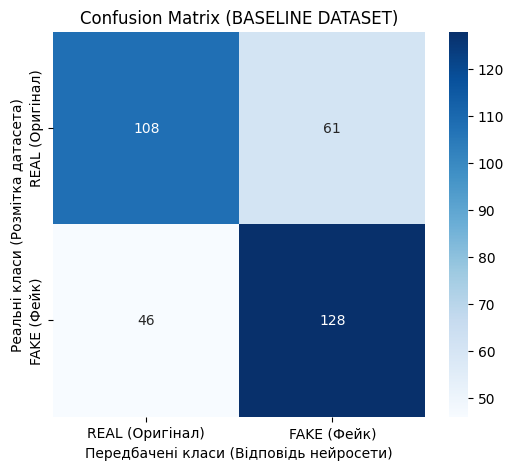


📊 Детальный академічний доклад по метрикам:
              precision    recall  f1-score   support

        REAL       0.70      0.64      0.67       169
        FAKE       0.68      0.74      0.71       174

    accuracy                           0.69       343
   macro avg       0.69      0.69      0.69       343
weighted avg       0.69      0.69      0.69       343



In [ ]:
import os
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# 1. ВКЛЮЧАЕМ УСТРОЙСТВО И ФИКСИРУЕМ РАНДОМ (чтобы экзамен был честным)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(42)

# 2. ПРАВИЛА ЗАГРУЗКИ ДАТАСЕТА
class ELADataset(Dataset):
    def __init__(self, folder_path, transform=None):
        self.folder_path = folder_path
        self.transform = transform
        self.image_files = [f for f in os.listdir(folder_path) if f.endswith('.jpg')]

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_name = self.image_files[idx]
        img_path = os.path.join(self.folder_path, img_name)
        image = Image.open(img_path).convert('RGB')
        label = 1 if img_name.startswith("FAKE") else 0
        if self.transform:
            image = self.transform(image)
        return image, label

transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
])

# ВАЖНО: Укажи тут правильную папку (если тестируешь ELA, то папку с ELA)
dataset = ELADataset(folder_path='/content/raw_dataset/', transform=transform)

train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)
print(f"📦 Дані завантажено. На екзамен надіслано: {len(test_dataset)} фото")

# 3. ЧЕРТЕЖ АРХИТЕКТУРЫ
class ELA_Scanner(nn.Module):
    def __init__(self):
        super(ELA_Scanner, self).__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        self.fc_layers = nn.Sequential(
            nn.Linear(32 * 32 * 32, 128),
            nn.ReLU(),
            nn.Linear(128, 2)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = x.view(x.size(0), -1)
        x = self.fc_layers(x)
        return x

# 4. СОЗДАЕМ СЕТЬ И ЗАГРУЖАЕМ ВЕСА
model = ELA_Scanner().to(device)

# ВАЖНО: Укажи тут правильный файл с весами ('model_ela_63ff.pth' или 'model_raw_baseline.pth')
model.load_state_dict(torch.load('model_raw_baseline.pth', map_location=device))
print("Ваги підзавантажено. Розрахунок метрик.\n")

# 5. СТРОИМ МАТРИЦУ ОШИБОК
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['REAL (Оригінал)', 'FAKE (Фейк)'],
            yticklabels=['REAL (Оригінал)', 'FAKE (Фейк)'])

plt.ylabel('Реальні класи (Розмітка датасета)')
plt.xlabel('Передбачені класи (Відповідь нейросети)')
plt.title('Confusion Matrix (BASELINE DATASET)')
plt.show()

print("\n📊 Детальный академічний доклад по метрикам:")
print(classification_report(all_labels, all_preds, target_names=['REAL', 'FAKE']))

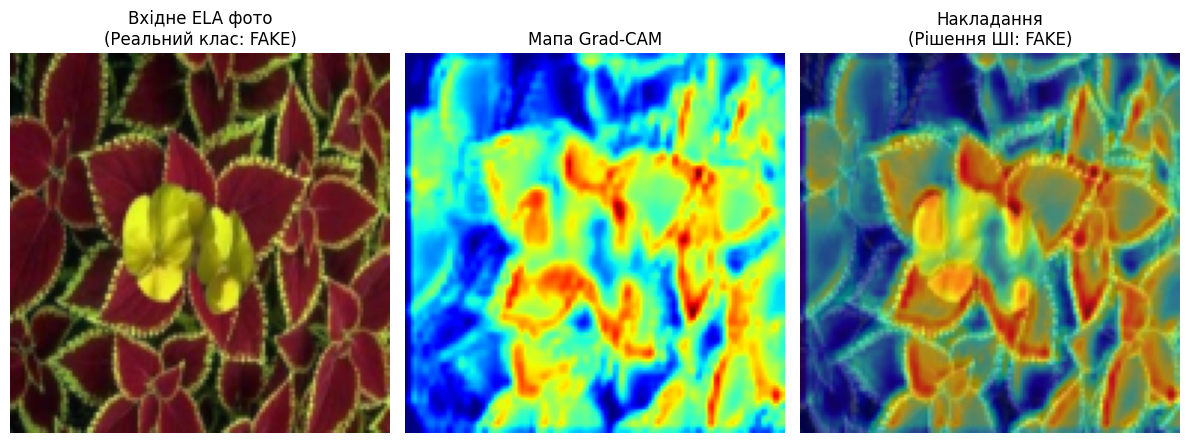

In [ ]:
!pip install -q grad-cam

import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

# 2. Настраиваем Grad-CAM для нашей сети
# Нам нужен самый последний сверточный слой.
# В нашей модели ELA_Scanner он находится внутри self.conv_layers
# под индексом 3 (nn.Conv2d(16, 32...))
target_layers = [model.conv_layers[-3]]

cam = GradCAM(model=model, target_layers=target_layers)

# 3. Достаем одну картинку из экзаменационной выборки
model.eval()
images, labels = next(iter(test_loader))

# Найдем первую картинку, которая реально является фейком (label == 1)
fake_idx = (labels == 1).nonzero(as_tuple=True)[0]
if len(fake_idx) > 0:
    index = fake_idx[0].item()
    input_tensor = images[index].unsqueeze(0).to(device)
    true_label = labels[index].item()
else:
    # Если в этой партии нет фейков, берем просто первую
    input_tensor = images[0].unsqueeze(0).to(device)
    index = 0

# 4. Узнаем, что думает нейросеть
with torch.no_grad():
    output = model(input_tensor)
    pred_class = torch.argmax(output).item()

# 5. Генерируем тепловую карту (просим сеть обосновать решение для предсказанного класса)
targets = [ClassifierOutputTarget(pred_class)]
grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0, :]

# 6. Красивая визуализация
# Переводим тензор картинки в формат для отрисовки (от 0 до 1, HxWxC)
img_to_draw = images[index].permute(1, 2, 0).numpy()
# Если трансформеры нормализовали картинку, приведем ее к диапазону 0-1
img_to_draw = (img_to_draw - img_to_draw.min()) / (img_to_draw.max() - img_to_draw.min())

# Накладываем тепловую карту на исходное ELA-изображение
visualization = show_cam_on_image(img_to_draw, grayscale_cam, use_rgb=True)

# 7. Вывод на экран
plt.figure(figsize=(12, 5))

plt.subplot(1, 3, 1)
plt.imshow(img_to_draw)
plt.title(f"Вхідне ELA фото\n(Реальний клас: {'FAKE' if true_label==1 else 'REAL'})")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(grayscale_cam, cmap='jet')
plt.title("Мапа Grad-CAM")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(visualization)
plt.title(f"Накладання\n(Рішення ШІ: {'FAKE' if pred_class==1 else 'REAL'})")
plt.axis('off')

plt.tight_layout()
plt.show()

📦 Данные загружены. На обучение: 1376, На экзамен: 345

⚙️ Загрузка и настройка ResNet18 (Transfer Learning)...

--- СТАРТ ОБУЧЕНИЯ (ТОЛЬКО ГОЛОВА) ---


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Епоха 1/5 завершена. Loss: 0.6668
Епоха 2/5 завершена. Loss: 0.6235
Епоха 3/5 завершена. Loss: 0.5918
Епоха 4/5 завершена. Loss: 0.5738
Епоха 5/5 завершена. Loss: 0.5604
✅ Новые веса сохранены в model_resnet_ela_frozen.pth

📊 Подготовка матрицы ошибок...


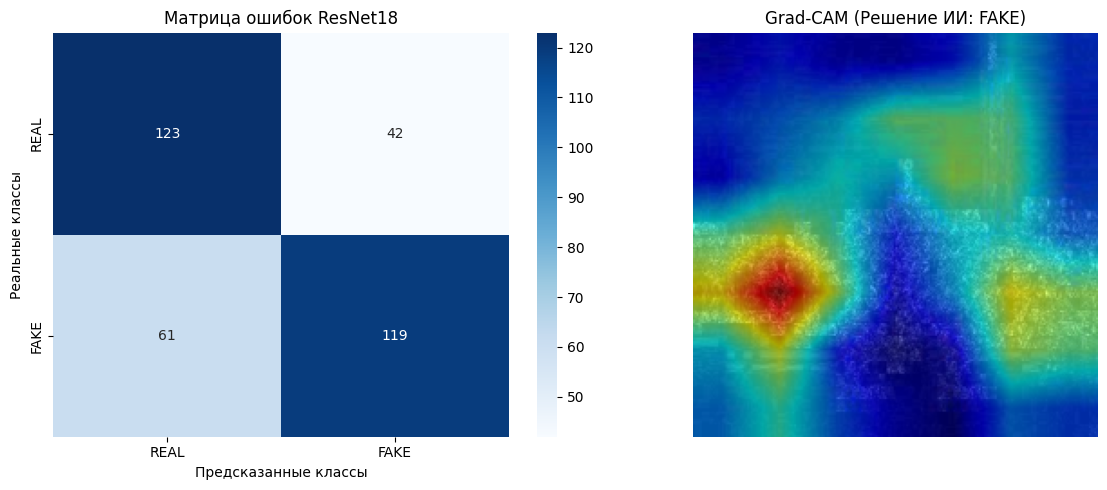


📊 Детальный академический отчет по метрикам ResNet18:
              precision    recall  f1-score   support

        REAL       0.67      0.75      0.70       165
        FAKE       0.74      0.66      0.70       180

    accuracy                           0.70       345
   macro avg       0.70      0.70      0.70       345
weighted avg       0.71      0.70      0.70       345



In [ ]:
!pip install -q grad-cam
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms, models
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import cv2
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

# 2. ВКЛЮЧАЕМ УСТРОЙСТВО И ФИКСИРУЕМ РАНДОМ
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(42)

class ELADataset(Dataset):
    def __init__(self, folder_path, transform=None):
        self.folder_path = folder_path
        self.transform = transform
        self.image_files = [f for f in os.listdir(folder_path) if f.endswith('.jpg') or f.endswith('.png')]

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_name = self.image_files[idx]
        img_path = os.path.join(self.folder_path, img_name)
        image = Image.open(img_path).convert('RGB')
        label = 1 if img_name.startswith("FAKE") else 0
        if self.transform:
            image = self.transform(image)
        return image, label

# 3. НОВЫЕ ТРАНСФОРМАЦИИ СПЕЦИАЛЬНО ДЛЯ RESNET (224x224 + Нормализация)
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# ВАЖНО: Укажи тут правильную папку с ELA-картинками
dataset = ELADataset(folder_path='/content/dataset/', transform=transform)

train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)
print(f"📦 Данные загружены. На обучение: {len(train_dataset)}, На экзамен: {len(test_dataset)}")

# 4. СОЗДАЕМ И "ЗАМОРАЖИВАЕМ" RESNET18
print("\n⚙️ Загрузка и настройка ResNet18 (Transfer Learning)...")
model = models.resnet18(pretrained=True)

# МАГИЯ ЗАМОРОЗКИ: Запрещаем Питону менять веса основной сети!
for param in model.parameters():
    param.requires_grad = False

# Меняем голову (она по умолчанию "разморожена", учиться будет ТОЛЬКО она)
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 2)
model = model.to(device)

# 5. БЫСТРОЕ ОБУЧЕНИЕ (Обучаем только последний слой)
criterion = nn.CrossEntropyLoss()
# Делаем шаг обучения в 5 раз меньше, чтобы действовать ювелирно
optimizer = optim.Adam(model.fc.parameters(), lr=0.0001)

epochs = 5
print("\n--- СТАРТ ОБУЧЕНИЯ (ТОЛЬКО ГОЛОВА) ---")
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    print(f"Епоха {epoch+1}/{epochs} завершена. Loss: {running_loss/len(train_loader):.4f}")

torch.save(model.state_dict(), 'model_resnet_ela_frozen.pth')
print("✅ Новые веса сохранены в model_resnet_ela_frozen.pth\n")

# 6. ЭКЗАМЕН И МАТРИЦА ОШИБОК
model.eval()
all_preds = []
all_labels = []

print("📊 Подготовка матрицы ошибок...")
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(12, 5))

# Отрисовка Матрицы
plt.subplot(1, 2, 1)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['REAL', 'FAKE'],
            yticklabels=['REAL', 'FAKE'])
plt.ylabel('Реальные классы')
plt.xlabel('Предсказанные классы')
plt.title('Матрица ошибок ResNet18')
for param in model.parameters():
    param.requires_grad = True
# 7. GRAD-CAM (ЦЕЛЕВОЙ СЛОЙ RESNET)
target_layers = [model.layer4[-1]]
cam = GradCAM(model=model, target_layers=target_layers)

# Берем батч картинок и ищем Фейк
images, labels = next(iter(test_loader))
fake_idx = (labels == 1).nonzero(as_tuple=True)[0]

if len(fake_idx) > 0:
    index = fake_idx[0].item()
    input_tensor = images[index].unsqueeze(0).to(device)
    true_label = labels[index].item()
else:
    input_tensor = images[0].unsqueeze(0).to(device)
    true_label = labels[0].item()
    index = 0

with torch.no_grad():
    output = model(input_tensor)
    pred_class = torch.argmax(output).item()

targets = [ClassifierOutputTarget(pred_class)]
grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0, :]

# ДЕНОРМАЛИЗАЦИЯ ДЛЯ ВИЗУАЛИЗАЦИИ
# Так как мы нормализовали пиксели для ResNet, их нужно "вернуть обратно", чтобы картинка не была темной
img_to_draw = images[index].cpu().permute(1, 2, 0).numpy()
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])
img_to_draw = std * img_to_draw + mean
img_to_draw = np.clip(img_to_draw, 0, 1) # Обрезаем значения, чтобы не выходили за рамки 0-1

visualization = show_cam_on_image(img_to_draw, grayscale_cam, use_rgb=True)

# Отрисовка Grad-CAM
plt.subplot(1, 2, 2)
plt.imshow(visualization)
plt.title(f"Grad-CAM (Решение ИИ: {'FAKE' if pred_class==1 else 'REAL'})")
plt.axis('off')

plt.tight_layout()
plt.show()

print("\n📊 Детальный академический отчет по метрикам ResNet18:")
print(classification_report(all_labels, all_preds, target_names=['REAL', 'FAKE']))

📦 Дані завантажені. На навчання: 1376, На екзамен: 345

⚙️ Завантаження і налаштування ResNet18 (Full Fine-Tuning)

--- ПОЧАТОК НАВЧАННЯ (FULL FINE-TUNING) ---


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Епоха 1/4 закінчена. Loss: 0.4898
Епоха 2/4 закінчена. Loss: 0.1732
Епоха 3/4 закінчена. Loss: 0.0644
Епоха 4/4 закінчена. Loss: 0.0304
✅ Фінальні ваги збережені в model_resnet_ela_finetuned.pth

Підготовка матриці помилок


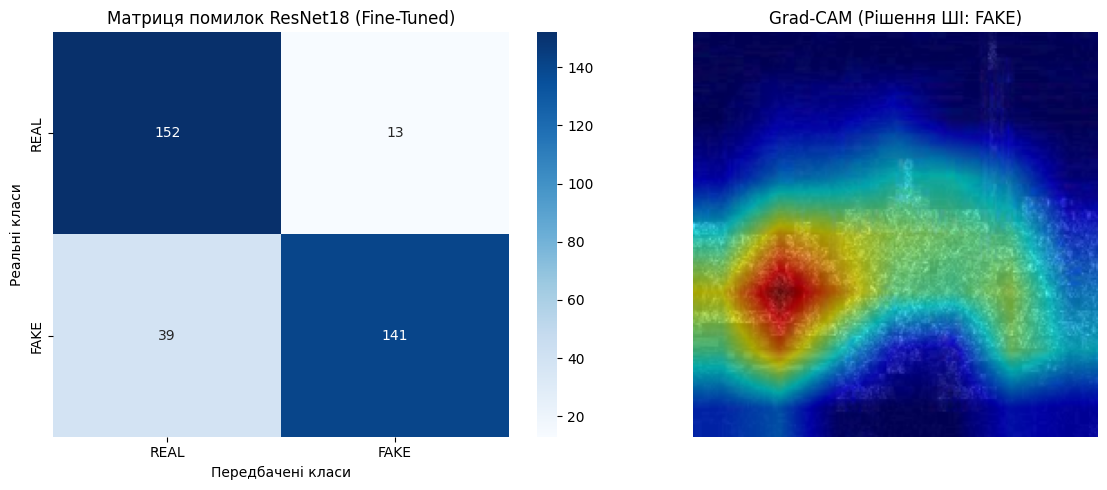


 Детальный академічний доклад по метрикам ResNet18 (Fine-Tuned):
              precision    recall  f1-score   support

        REAL       0.80      0.92      0.85       165
        FAKE       0.92      0.78      0.84       180

    accuracy                           0.85       345
   macro avg       0.86      0.85      0.85       345
weighted avg       0.86      0.85      0.85       345



In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms, models
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import cv2
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

# 1. ВКЛЮЧАЕМ УСТРОЙСТВО И ФИКСИРУЕМ РАНДОМ
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(42)

class ELADataset(Dataset):
    def __init__(self, folder_path, transform=None):
        self.folder_path = folder_path
        self.transform = transform
        self.image_files = [f for f in os.listdir(folder_path) if f.endswith('.jpg') or f.endswith('.png')]

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_name = self.image_files[idx]
        img_path = os.path.join(self.folder_path, img_name)
        image = Image.open(img_path).convert('RGB')
        label = 1 if img_name.startswith("FAKE") else 0
        if self.transform:
            image = self.transform(image)
        return image, label

# 2. ТРАНСФОРМАЦИИ ДЛЯ RESNET
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# ВАЖНО: Укажи тут правильную папку с ELA-картинками
dataset = ELADataset(folder_path='/content/dataset/', transform=transform)

train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)
print(f"📦 Дані завантажені. На навчання: {len(train_dataset)}, На екзамен: {len(test_dataset)}")

# 3. СОЗДАЕМ RESNET18 (БЕЗ ЗАМОРОЗКИ!)
print("\n⚙️ Завантаження і налаштування ResNet18 (Full Fine-Tuning)")
model = models.resnet18(pretrained=True)

# Мы удалили цикл заморозки. Теперь вся сеть готова аккуратно учиться.
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 2)
model = model.to(device)

# 4. ЮВЕЛИРНОЕ ОБУЧЕНИЕ ВСЕХ СЛОЕВ
criterion = nn.CrossEntropyLoss()
# ВАЖНО: Передаем model.parameters(), а не model.fc. И ставим микро-шаг!
optimizer = optim.Adam(model.parameters(), lr=0.00005)

epochs = 4 # 4 эпохи для тонкой настройки достаточно
print("\n--- ПОЧАТОК НАВЧАННЯ (FULL FINE-TUNING) ---")
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    print(f"Епоха {epoch+1}/{epochs} закінчена. Loss: {running_loss/len(train_loader):.4f}")

torch.save(model.state_dict(), 'model_resnet_ela_finetuned.pth')
print("✅ Фінальні ваги збережені в model_resnet_ela_finetuned.pth\n")

# 5. ЭКЗАМЕН И МАТРИЦА ОШИБОК
model.eval()
all_preds = []
all_labels = []

print("Підготовка матриці помилок")
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(12, 5))

# Отрисовка Матрицы
plt.subplot(1, 2, 1)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['REAL', 'FAKE'],
            yticklabels=['REAL', 'FAKE'])
plt.ylabel('Реальні класи')
plt.xlabel('Передбачені класи')
plt.title('Матриця помилок ResNet18 (Fine-Tuned)')

# 6. GRAD-CAM (Сеть не заморожена, костыли больше не нужны)
target_layers = [model.layer4[-1]]
cam = GradCAM(model=model, target_layers=target_layers)

# Берем батч картинок и ищем Фейк
images, labels = next(iter(test_loader))
fake_idx = (labels == 1).nonzero(as_tuple=True)[0]

if len(fake_idx) > 0:
    index = fake_idx[0].item()
    input_tensor = images[index].unsqueeze(0).to(device)
    true_label = labels[index].item()
else:
    input_tensor = images[0].unsqueeze(0).to(device)
    true_label = labels[0].item()
    index = 0

with torch.no_grad():
    output = model(input_tensor)
    pred_class = torch.argmax(output).item()

targets = [ClassifierOutputTarget(pred_class)]
grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0, :]

# ДЕНОРМАЛИЗАЦИЯ ДЛЯ ВИЗУАЛИЗАЦИИ
img_to_draw = images[index].cpu().permute(1, 2, 0).numpy()
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])
img_to_draw = std * img_to_draw + mean
img_to_draw = np.clip(img_to_draw, 0, 1)

visualization = show_cam_on_image(img_to_draw, grayscale_cam, use_rgb=True)

# Отрисовка Grad-CAM
plt.subplot(1, 2, 2)
plt.imshow(visualization)
plt.title(f"Grad-CAM (Рішення ШІ: {'FAKE' if pred_class==1 else 'REAL'})")
plt.axis('off')

plt.tight_layout()
plt.show()

print("\n Детальный академічний доклад по метрикам ResNet18 (Fine-Tuned):")
print(classification_report(all_labels, all_preds, target_names=['REAL', 'FAKE']))

In [5]:
# 1. РАСПАКОВКА (БЕЗ ФЛАГА -j !!!
!unzip -q "/content/drive/MyDrive/Colab Notebooks/CASIA_Unified_Randomized_v2.zip" -d /content/

 GPU активований! Відеокарта: Tesla T4

📁 Чтение логов для Source-Aware Split...
Количество файлов на источник: {4: 11423}

📈 ПЕРЕВІРКА НА УТЕЧКУ (DATA LEAKAGE) — ELA Source-Aware:
Train: 41124 | Val: 4568
Унікальних оригіналів Train: 10281 | Val: 1142
Перетинів оригіналів: 0

📄 Манифест сплита сохранен: /content/ela_sourceaware_split_v2.csv

На навчання (Train): 41124
На валідацію (Val): 4568
На фінальний екзамен (Test): 11432

⚙️ Завантаження і налаштування ResNet18 (Full Fine-Tuning)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 180MB/s]



--- ПОЧАТОК НАВЧАННЯ (ELA SOURCE-AWARE V2) ---
Епоха 01 | LR: 5.0e-05 | Train Loss: 0.6089 | Val Loss: 0.6037 | Val Acc: 0.6883
  -> Збережено найкращу модель!
Епоха 02 | LR: 5.0e-05 | Train Loss: 0.5201 | Val Loss: 0.6149 | Val Acc: 0.6867
Епоха 03 | LR: 5.0e-05 | Train Loss: 0.4026 | Val Loss: 0.6927 | Val Acc: 0.6703
Епоха 04 | LR: 5.0e-05 | Train Loss: 0.2797 | Val Loss: 0.8452 | Val Acc: 0.6806
Епоха 05 | LR: 2.5e-05 | Train Loss: 0.1909 | Val Loss: 0.8603 | Val Acc: 0.6723

⚠️ Рання зупинка на епосі 5. Мережа досягла максимуму.

Завантажуємо найкращі ваги для фінального екзамену...
📄 Предикти збережено: /content/ela_sourceaware_test_predictions.csv


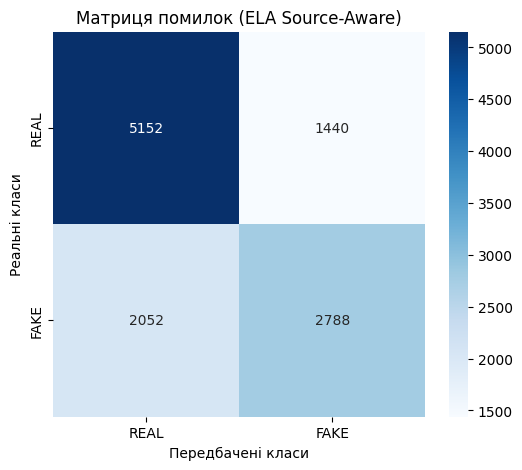


 Детальний академічний доклад по метрикам (На Test-датасеті, порог 0.5):
              precision    recall  f1-score   support

        REAL       0.72      0.78      0.75      6592
        FAKE       0.66      0.58      0.61      4840

    accuracy                           0.69     11432
   macro avg       0.69      0.68      0.68     11432
weighted avg       0.69      0.69      0.69     11432



In [ ]:
import os
import csv
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import transforms, models
from PIL import Image
import numpy as np
import random
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from collections import Counter

# 1. ЖЕЛЕЗОБЕТОННАЯ ФИКСАЦИЯ СЛУЧАЙНОСТИ
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)
    print(f" GPU активований! Відеокарта: {torch.cuda.get_device_name(0)}")
else:
    print("Увага: це процесор!")

# 2. КЛАСС ДАТАСЕТА
class ELADataset(Dataset):
    def __init__(self, folder_path, transform=None):
        self.transform = transform
        self.samples = []
        for label_name, label_idx in [("REAL", 0), ("FAKE", 1)]:
            class_dir = os.path.join(folder_path, label_name)
            if not os.path.exists(class_dir): continue
            for filename in os.listdir(class_dir):
                if filename.lower().endswith((".png", ".jpg", ".jpeg")):
                    self.samples.append((os.path.join(class_dir, filename), label_idx))
    def __len__(self): return len(self.samples)
    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        image = Image.open(img_path).convert("RGB")
        if self.transform: image = self.transform(image)
        return image, label

# 3. ТРАНСФОРМАЦИИ
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 4. ЗАГРУЗКА ДАННЫХ И СТРОГИЙ SOURCE-AWARE SPLIT
train_dir = '/content/CASIA_Unified_Randomized_v2/train'
test_dir = '/content/CASIA_Unified_Randomized_v2/test'
csv_path = '/content/CASIA_Unified_Randomized_v2/dataset_log.csv'

full_train_dataset = ELADataset(folder_path=train_dir, transform=transform)
test_dataset = ELADataset(folder_path=test_dir, transform=transform)

print("\n📁 Чтение логов для Source-Aware Split...")
file_to_source = {}
with open(csv_path, encoding="utf-8") as f:
    reader = csv.DictReader(f)
    for row in reader:
        file_to_source[row["filename"]] = (
            row["source_dataset"],
            row["original_filename"]
        )

# Проверка на отсутствие пропусков в логе
missing = []
for path, _ in full_train_dataset.samples:
    name = os.path.basename(path)
    if name not in file_to_source:
        missing.append(name)

if missing:
    raise RuntimeError(f"В CSV отсутствуют {len(missing)} файлов. Примеры: {missing[:5]}")

# Диагностика количества аугментаций на источник
source_counts = Counter(
    file_to_source[os.path.basename(path)]
    for path, _ in full_train_dataset.samples
)
count_distribution = Counter(source_counts.values())
print(f"Количество файлов на источник: {dict(count_distribution)}")

# Формируем уникальные источники
unique_sources = sorted({
    file_to_source[os.path.basename(path)]
    for path, _ in full_train_dataset.samples
})

rng = random.Random(42)
rng.shuffle(unique_sources)

val_count = round(len(unique_sources) * 0.1)
val_sources = set(unique_sources[:val_count])

train_indices, val_indices = [], []
for idx, (path, _) in enumerate(full_train_dataset.samples):
    filename = os.path.basename(path)
    source_key = file_to_source[filename]
    if source_key in val_sources:
        val_indices.append(idx)
    else:
        train_indices.append(idx)

# Защита от ошибок
assert len(train_indices) > 0, "Train indices пуст!"
assert len(val_indices) > 0, "Val indices пуст!"
assert len(train_indices) + len(val_indices) == len(full_train_dataset), "Сумма Train и Val не совпадает с датасетом!"

train_subset = Subset(full_train_dataset, train_indices)
val_subset = Subset(full_train_dataset, val_indices)

# Строгая проверка на пересечение (Data Leakage check)
train_sources_check = {file_to_source[os.path.basename(full_train_dataset.samples[i][0])] for i in train_indices}
val_sources_check = {file_to_source[os.path.basename(full_train_dataset.samples[i][0])] for i in val_indices}
intersection = train_sources_check & val_sources_check

print("\n" + "="*50)
print("📈 ПЕРЕВІРКА НА УТЕЧКУ (DATA LEAKAGE) — ELA Source-Aware:")
print(f"Train: {len(train_indices)} | Val: {len(val_indices)}")
print(f"Унікальних оригіналів Train: {len(train_sources_check)} | Val: {len(val_sources_check)}")
print(f"Перетинів оригіналів: {len(intersection)}")
print("="*50 + "\n")

assert len(intersection) == 0, "Обнаружена утечка исходников!"

# Сохраняем манифест сплита для 100% воспроизводимости
split_manifest_path = "/content/ela_sourceaware_split_v2.csv"
with open(split_manifest_path, "w", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)
    writer.writerow(["source_dataset", "original_filename", "subset"])
    for source_dataset, original_filename in sorted(train_sources_check):
        writer.writerow([source_dataset, original_filename, "train"])
    for source_dataset, original_filename in sorted(val_sources_check):
        writer.writerow([source_dataset, original_filename, "val"])
print(f"📄 Манифест сплита сохранен: {split_manifest_path}")

train_loader = DataLoader(train_subset, batch_size=32, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_subset, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

print(f"\nНа навчання (Train): {len(train_subset)}")
print(f"На валідацію (Val): {len(val_subset)}")
print(f"На фінальний екзамен (Test): {len(test_dataset)}\n")

# 5. СОЗДАЕМ RESNET18
print("⚙️ Завантаження і налаштування ResNet18 (Full Fine-Tuning)")
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
model.fc = nn.Linear(model.fc.in_features, 2)
model = model.to(device)

# 6. УМНОЕ ОБУЧЕНИЕ (ADAMW + REDUCE LR + LABEL SMOOTHING)
criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
optimizer = optim.AdamW(model.parameters(), lr=5e-5, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

epochs = 8
best_val_loss = float("inf")
patience_early_stop, patience_counter = 4, 0
best_model_path = '/content/model_resnet_ela_sourceaware_v2.pth'

print("\n--- ПОЧАТОК НАВЧАННЯ (ELA SOURCE-AWARE V2) ---")
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    train_loss = running_loss / len(train_loader)

    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss /= len(val_loader)
    val_acc = val_correct / val_total
    current_lr = optimizer.param_groups[0]['lr']

    print(f"Епоха {epoch+1:02d} | LR: {current_lr:.1e} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")
    scheduler.step(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), best_model_path)
        print("  -> Збережено найкращу модель!")
    else:
        patience_counter += 1
        if patience_counter >= patience_early_stop:
            print(f"\n⚠️ Рання зупинка на епосі {epoch+1}. Мережа досягла максимуму.")
            break

# 7. ЭКЗАМЕН НА ТЕСТОВОЙ ВЫБОРКЕ
print("\nЗавантажуємо найкращі ваги для фінального екзамену...")
model.load_state_dict(torch.load(best_model_path, map_location=device))
model.eval()

all_preds, all_labels, all_probs, all_filenames = [], [], [], []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)[:, 1] # Вероятность FAKE
        predicted = torch.argmax(outputs, dim=1)

        all_probs.extend(probs.cpu().numpy())
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

# Сохраняем предсказания с вероятностями (как в RGB скрипте)
test_filenames = [os.path.basename(p) for p, _ in test_dataset.samples]
predictions_csv_path = "/content/ela_sourceaware_test_predictions.csv"
df_preds = pd.DataFrame({
    'filename': test_filenames,
    'true_label': all_labels,
    'pred_label': all_preds,
    'prob_fake': all_probs
})
df_preds.to_csv(predictions_csv_path, index=False)
print(f"📄 Предикти збережено: {predictions_csv_path}")

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['REAL', 'FAKE'], yticklabels=['REAL', 'FAKE'])
plt.ylabel('Реальні класи')
plt.xlabel('Передбачені класи')
plt.title('Матриця помилок (ELA Source-Aware)')
plt.show()

print("\n Детальний академічний доклад по метрикам (На Test-датасеті, порог 0.5):")
print(classification_report(all_labels, all_preds, target_names=['REAL', 'FAKE']))

In [ ]:
!ls -lh /content

total 43M
drwxr-xr-x 4 root root 4.0K Jul  5 11:48 CASIA_Unified_Randomized_v2
drwx------ 5 root root 4.0K Jul  5 11:38 drive
-rw-r--r-- 1 root root  43M Jul  5 12:03 model_resnet_ela_finetuned.pth
drwxr-xr-x 1 root root 4.0K Jun  4 13:39 sample_data


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!apt-get -qq update
!apt-get -qq install unrar
!unrar x "/content/drive/MyDrive/Colab Notebooks/CASIA_Unified_Randomized_v2.zip.rar" /content/

Streaming output truncated to the last 5000 lines.
Extracting  /content/CASIA_Unified_Randomized_RGB_v1/train/REAL/CASIA2_REAL_Au_pla_30299_aug2.png      92%  OK 
Extracting  /content/CASIA_Unified_Randomized_RGB_v1/train/REAL/CASIA2_REAL_Au_pla_30299_aug3.png      92%  OK 
Extracting  /content/CASIA_Unified_Randomized_RGB_v1/train/REAL/CASIA2_REAL_Au_pla_30299_aug4.png      92%  OK 
Extracting  /content/CASIA_Unified_Randomized_RGB_v1/train/REAL/CASIA2_REAL_Au_pla_30300_aug1.png      92%  OK 
Extracting  /content/CASIA_Unified_Randomized_RGB_v1/train/REAL/CASIA2_REAL_Au_pla_30300_aug2.png      92%  OK 
Extracting  /content/CASIA_Unified_Randomized_RGB_v1/train/REAL/CASIA2_REAL_Au_pla_30300_aug3.png      92%  OK 
Extracting  /content/CASIA_Unified_Randomized_RGB_v1/train/REAL/CASIA2_REAL_Au_pla_30300_aug4.png      92%  OK 
Extracting  /content/CASIA_Unified_Randomized_RGB_v1/train/REAL/CASIA2_REAL_Au_pla_30301_aug1.png     

In [ ]:
/content/dataset.zip

-rw-r--r-- 1 root root 12G Jul 12 21:55 dataset.zip


In [ ]:
!zipinfo dataset.zip

Archive:  dataset.zip
Zip file size: 12463387197 bytes, number of entries: 62939

warning [dataset.zip]:  end-of-central-directory record claims this
  is disk 7301 but that the central directory starts on disk 34861; this is a
  contradiction.  Attempting to process anyway.
warning [dataset.zip]:  814121317 extra bytes at beginning or within zipfile
  (attempting to process anyway)
error [dataset.zip]:  start of central directory not found;
  zipfile corrupt.
  (please check that you have transferred or created the zipfile in the
  appropriate BINARY mode and that you have compiled UnZip properly)


 GPU активований! Відеокарта: Tesla T4

📈 ПЕРЕВІРКА НА УТЕЧКУ (DATA LEAKAGE) — RGB:
Файлів у Train-папці: 45692
Train: 41124 | Val: 4568
Унікальних оригіналів Train: 10281 | Val: 1142
Перетинів оригіналів: 0

✅ Утечок немає. Можна продовжувати.
⚙️ Завантаження ResNet18 (Full Fine-Tuning) — RGB baseline
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 129MB/s]



--- ПОЧАТОК НАВЧАННЯ (RGB BASELINE) ---
Епоха 01 | LR: 5.0e-05 | Train Loss: 0.4745 | Val Loss: 0.6354 | Val Acc: 0.6924
  -> Збережено найкращу модель!
Епоха 02 | LR: 5.0e-05 | Train Loss: 0.3585 | Val Loss: 0.6960 | Val Acc: 0.6806
Епоха 03 | LR: 5.0e-05 | Train Loss: 0.3128 | Val Loss: 0.7553 | Val Acc: 0.6913
Епоха 04 | LR: 5.0e-05 | Train Loss: 0.2751 | Val Loss: 0.8425 | Val Acc: 0.6681
Епоха 05 | LR: 2.5e-05 | Train Loss: 0.2229 | Val Loss: 0.9030 | Val Acc: 0.6845

⚠️ Рання зупинка на епосі 5.

Завантажуємо найкращі ваги для фінального екзамену...
📄 Предикти збережено: /content/rgb_test_predictions.csv


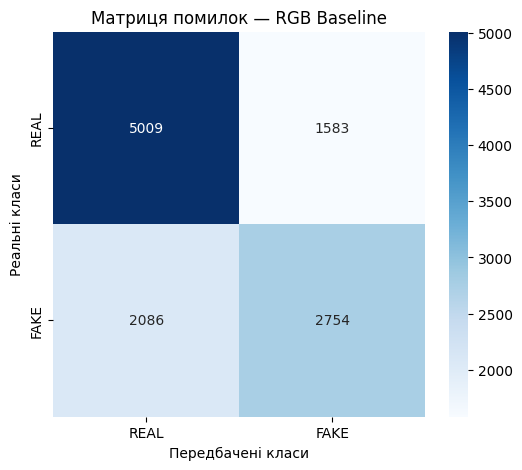


📊 Детальний звіт по метриках (RGB Test-датасет):
              precision    recall  f1-score   support

        REAL       0.71      0.76      0.73      6592
        FAKE       0.64      0.57      0.60      4840

    accuracy                           0.68     11432
   macro avg       0.67      0.66      0.67     11432
weighted avg       0.68      0.68      0.68     11432



In [ ]:
# ============================================================
# RGB BASELINE TRAINING SCRIPT (KAGGLE EDITION)
# ============================================================

import os
import csv
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import transforms, models
from PIL import Image
import numpy as np
import random
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# 1. ЖЕЛЕЗОБЕТОННАЯ ФІКСАЦІЯ ВИПАДКОВОСТІ
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)
    print(f" GPU активований! Відеокарта: {torch.cuda.get_device_name(0)}")
else:
    print("Увага: це процесор!")

# 2. КЛАС ДАТАСЕТУ (generic — працює і для RGB)
class ImageDataset(Dataset):
    def __init__(self, folder_path, transform=None):
        self.transform = transform
        self.samples = []
        for label_name, label_idx in [("REAL", 0), ("FAKE", 1)]:
            class_dir = os.path.join(folder_path, label_name)
            if not os.path.exists(class_dir): continue
            for filename in os.listdir(class_dir):
                if filename.lower().endswith((".png", ".jpg", ".jpeg")):
                    self.samples.append((os.path.join(class_dir, filename), label_idx))
    def __len__(self): return len(self.samples)
    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        image = Image.open(img_path).convert("RGB")
        if self.transform: image = self.transform(image)
        return image, label

# 3. ТРАНСФОРМАЦІЇ (ImageNet-нормалізація)
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 4. ЗАВАНТАЖЕННЯ + "ЧЕСНИЙ" SPLIT ДЛЯ ВАЛІДАЦІЇ
# 🔧 ПУТИ KAGGLE: Убедись, что 'casia-unified-randomized-v2' совпадает с названием в Input
KAGGLE_INPUT_DIR = '/content/CASIA_Unified_Randomized_RGB_v2'
train_dir = f'{KAGGLE_INPUT_DIR}/train'
test_dir = f'{KAGGLE_INPUT_DIR}/test'

full_train_dataset = ImageDataset(folder_path=train_dir, transform=transform)
test_dataset = ImageDataset(folder_path=test_dir, transform=transform)

# -----------------------------
# ЧЕСНИЙ SPLIT ПО ORIGINAL_FILENAME (Захист від Data Leakage)
# -----------------------------
csv_path = os.path.join(KAGGLE_INPUT_DIR, "dataset_log.csv")
file_to_original = {}

with open(csv_path, encoding="utf-8") as f:
    reader = csv.DictReader(f)
    for row in reader:
        file_to_original[row["filename"]] = row["original_filename"]

missing = []
for path, _ in full_train_dataset.samples:
    name = os.path.basename(path)
    if name not in file_to_original:
        missing.append(name)

if missing:
    raise RuntimeError(
        f"В CSV-логі відсутні {len(missing)} файлів, які є в папці.\n"
        f"Приклади пропущених файлів: {missing[:5]}"
    )

unique_originals = sorted({
    file_to_original[os.path.basename(path)]
    for path, _ in full_train_dataset.samples
})

rng = random.Random(42)
rng.shuffle(unique_originals)

val_count = round(len(unique_originals) * 0.1)
val_originals = set(unique_originals[:val_count])

train_indices, val_indices = [], []
for idx, (path, _) in enumerate(full_train_dataset.samples):
    filename = os.path.basename(path)
    original = file_to_original[filename]
    (val_indices if original in val_originals else train_indices).append(idx)

train_subset = Subset(full_train_dataset, train_indices)
val_subset = Subset(full_train_dataset, val_indices)

train_originals = {file_to_original[os.path.basename(full_train_dataset.samples[i][0])] for i in train_indices}
val_originals_check = {file_to_original[os.path.basename(full_train_dataset.samples[i][0])] for i in val_indices}
intersection = train_originals & val_originals_check

print("\n" + "="*50)
print("📈 ПЕРЕВІРКА НА УТЕЧКУ (DATA LEAKAGE) — RGB:")
print(f"Файлів у Train-папці: {len(full_train_dataset.samples)}")
print(f"Train: {len(train_indices)} | Val: {len(val_indices)}")
print(f"Унікальних оригіналів Train: {len(train_originals)} | Val: {len(val_originals_check)}")
print(f"Перетинів оригіналів: {len(intersection)}")
print("="*50 + "\n")

if len(intersection) > 0:
    print("⚠️ УВАГА: Виявлено утечку даних!")
else:
    print("✅ Утечок немає. Можна продовжувати.")

train_loader = DataLoader(train_subset, batch_size=32, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_subset, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

# 5. RESNET18 — той самий backbone, що й для ELA (для чесного порівняння)
print("⚙️ Завантаження ResNet18 (Full Fine-Tuning) — RGB baseline")
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
model.fc = nn.Linear(model.fc.in_features, 2)
model = model.to(device)

# 6. НАВЧАННЯ — гіперпараметри НЕ ЗМІНЕНІ
criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
optimizer = optim.AdamW(model.parameters(), lr=5e-5, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

epochs = 8
best_val_loss = float("inf")
patience_early_stop, patience_counter = 4, 0

# Сохраняем модель в рабочую папку Kaggle
best_model_path = '/content/model_resnet_rgb_LATEST.pth'

print("\n--- ПОЧАТОК НАВЧАННЯ (RGB BASELINE) ---")
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    train_loss = running_loss / len(train_loader)

    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss /= len(val_loader)
    val_acc = val_correct / val_total
    current_lr = optimizer.param_groups[0]['lr']
    print(f"Епоха {epoch+1:02d} | LR: {current_lr:.1e} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")
    scheduler.step(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), best_model_path)
        print("  -> Збережено найкращу модель!")
    else:
        patience_counter += 1
        if patience_counter >= patience_early_stop:
            print(f"\n⚠️ Рання зупинка на епосі {epoch+1}.")
            break

# 7. ЕКЗАМЕН НА ТЕСТОВІЙ ВИБІРЦІ
print("\nЗавантажуємо найкращі ваги для фінального екзамену...")
model.load_state_dict(torch.load(best_model_path))
model.eval()

all_preds, all_labels, all_probs, all_filenames = [], [], [], []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs[:, 1].cpu().numpy())  # Вероятность класса FAKE

# 8. ЛОГИРОВАНИЕ ПРЕДСКАЗАНИЙ В CSV (Секретное оружие для будущего Fusion)
test_filenames = [os.path.basename(p) for p, _ in test_dataset.samples]
predictions_csv_path = "/content/rgb_test_predictions.csv"

df_preds = pd.DataFrame({
    'filename': test_filenames,
    'true_label': all_labels,
    'pred_label': all_preds,
    'prob_fake': all_probs
})
df_preds.to_csv(predictions_csv_path, index=False)
print(f"📄 Предикти збережено: {predictions_csv_path}")

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['REAL', 'FAKE'], yticklabels=['REAL', 'FAKE'])
plt.ylabel('Реальні класи')
plt.xlabel('Передбачені класи')
plt.title('Матриця помилок — RGB Baseline')
plt.savefig('/content/rgb_confusion_matrix.png')
plt.show()

print("\n📊 Детальний звіт по метриках (RGB Test-датасет):")
print(classification_report(all_labels, all_preds, target_names=['REAL', 'FAKE']))

🚀 Запуск Late Feature Fusion на cuda
📁 Чтение логов и сборка Source-Aware датасетов...
✅ Split завершен. Train: 41124, Val: 4568, Test: 11432

⚙️ Инициализация Late Feature Fusion Модели...

🚀 СТАРТ ОБУЧЕНИЯ (Обучается только MLP, бэкенды заморожены)...
Эпоха 01/15 | Train Loss: 0.3038 | Val Loss: 0.6211
  [+] Сохранена лучшая модель MLP-фьюжена
Эпоха 02/15 | Train Loss: 0.2709 | Val Loss: 0.6232
Эпоха 03/15 | Train Loss: 0.2595 | Val Loss: 0.6075
  [+] Сохранена лучшая модель MLP-фьюжена
Эпоха 04/15 | Train Loss: 0.2579 | Val Loss: 0.6654
Эпоха 05/15 | Train Loss: 0.2485 | Val Loss: 0.7085
Эпоха 06/15 | Train Loss: 0.2487 | Val Loss: 0.6743
Эпоха 07/15 | Train Loss: 0.2336 | Val Loss: 0.7072
🛑 Early stopping на эпохе 7

🔍 ПОИСК ПОРОГА НА VALIDATION ВЫБОРКЕ...
✅ Оптимальный порог (F1) найден: 0.2443

🎯 ЭКЗАМЕН FUSION-МОДЕЛИ НА ИЗОЛИРОВАННОМ ТЕСТЕ...


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()



📊 ФИНАЛЬНЫЙ ОТЧЕТ: FUSION (Порог: 0.2443)
              precision    recall  f1-score   support

        REAL       0.89      0.61      0.72      6592
        FAKE       0.63      0.90      0.74      4840

    accuracy                           0.73     11432
   macro avg       0.76      0.75      0.73     11432
weighted avg       0.78      0.73      0.73     11432

📄 Метаданные предсказаний сохранены: /content/artifacts/fusion/fusion_test_metadata.csv
💾 Эмбеддинги и метки классов успешно экспортированы в /content/artifacts/fusion!
✅ Графики сохранены: /content/artifacts/fusion/thesis_fusion_eval.png


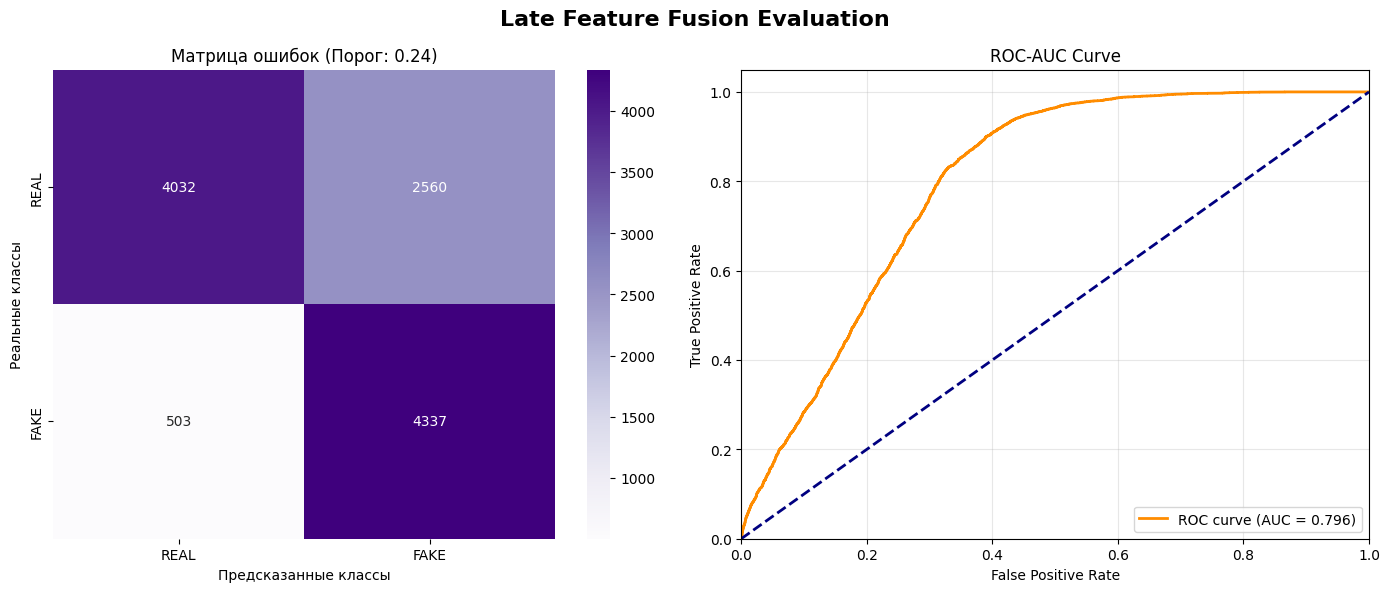

In [ ]:
"""
LATE FEATURE FUSION (RGB + ELA) - PRODUCTION & THESIS VERSION
---------------------------------
Архитектура:
1. Frozen RGB ResNet18 -> 512-d
2. Frozen ELA ResNet18 -> 512-d
3. Concatenation -> 1024-d
4. Trainable MLP Head (No BatchNorm) -> 2 classes

Улучшения:
- Готовый FusionDataset (жесткая проверка пар, сортировка, чтение с диска)
- Строгий Source-Aware Split с учетом 4 элементов в samples
- Поиск порога строго на Validation
- LR 3e-4 для стабильного fine-tuning
- Экспорт эмбеддингов, логитов и метаданных для t-SNE/PCA анализа
"""

import os
import csv
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import transforms, models
from PIL import Image
import numpy as np
import random
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, f1_score
from pathlib import Path

# ==========================================
# 1. ФИКСАЦИЯ СИДОВ (Для строгой научности)
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

print(f"🚀 Запуск Late Feature Fusion на {device}")

# ==========================================
# 2. НАСТРОЙКИ ПУТЕЙ (ДЛЯ GOOGLE COLAB)
# ==========================================
ROOT_DIR = Path("/content")

# Разделенные пути для RGB и ELA датасетов
RGB_DATASET_DIR = ROOT_DIR / "CASIA_Unified_Randomized_RGB_v1"
ELA_DATASET_DIR = ROOT_DIR / "CASIA_Unified_Randomized_v2"
CSV_LOG_PATH = ELA_DATASET_DIR / "dataset_log.csv"  # Лог берем из ELA, так как там формировались аугментации

# ПУТИ К ВЕСАМ НА GOOGLE DRIVE
DRIVE_DIR = Path("/content/drive/MyDrive/Colab Notebooks")

RGB_MODEL_PATH = DRIVE_DIR / "models/model_resnet_rgb_LATEST.pth"
ELA_MODEL_PATH = DRIVE_DIR / "models/model_resnet_ela_LATEST_Kaggle_5.pth"

# Пути для сохранения результатов
FUSION_OUT_DIR = ROOT_DIR / "artifacts" / "fusion"
FUSION_OUT_DIR.mkdir(parents=True, exist_ok=True)
FUSION_MODEL_SAVE = DRIVE_DIR / "model_fusion_LATEST.pth"

# ==========================================
# 3. ФУНДАМЕНТАЛЬНЫЙ ДАТАСЕТ
# ==========================================
class FusionDataset(Dataset):
    def __init__(self, rgb_dir, ela_dir, transform_rgb=None, transform_ela=None):
        self.rgb_dir = rgb_dir
        self.ela_dir = ela_dir
        self.transform_rgb = transform_rgb
        self.transform_ela = transform_ela
        self.samples = []

        for label_name, label_idx in [("REAL", 0), ("FAKE", 1)]:
            rgb_class_dir = os.path.join(self.rgb_dir, label_name)
            ela_class_dir = os.path.join(self.ela_dir, label_name)

            assert os.path.exists(rgb_class_dir), f"Directory not found: {rgb_class_dir}"
            assert os.path.exists(ela_class_dir), f"Directory not found: {ela_class_dir}"

            filenames = sorted(os.listdir(ela_class_dir))

            for filename in filenames:
                if filename.lower().endswith((".png", ".jpg", ".jpeg")):
                    ela_path = os.path.join(ela_class_dir, filename)
                    rgb_path = os.path.join(rgb_class_dir, filename)

                    assert os.path.exists(rgb_path), f"Missing RGB pair for {filename} in {rgb_class_dir}"
                    self.samples.append((rgb_path, ela_path, label_idx, filename))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        rgb_path, ela_path, label, filename = self.samples[idx]

        img_rgb = Image.open(rgb_path).convert("RGB")
        img_ela = Image.open(ela_path).convert("RGB")

        if self.transform_rgb:
            tensor_rgb = self.transform_rgb(img_rgb)
        else:
            tensor_rgb = img_rgb

        if self.transform_ela:
            tensor_ela = self.transform_ela(img_ela)
        else:
            tensor_ela = img_ela

        return tensor_rgb, tensor_ela, label, filename

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# ==========================================
# 4. АРХИТЕКТУРА LATE FUSION
# ==========================================
class LateFusionModel(nn.Module):
    def __init__(self, rgb_weights, ela_weights):
        super(LateFusionModel, self).__init__()

        # Загружаем RGB ветку
        self.rgb_branch = models.resnet18(weights=None)
        self.rgb_branch.fc = nn.Linear(self.rgb_branch.fc.in_features, 2)
        self.rgb_branch.load_state_dict(torch.load(rgb_weights, map_location=device))
        self.rgb_branch.fc = nn.Identity()

        # Загружаем ELA ветку
        self.ela_branch = models.resnet18(weights=None)
        self.ela_branch.fc = nn.Linear(self.ela_branch.fc.in_features, 2)
        self.ela_branch.load_state_dict(torch.load(ela_weights, map_location=device))
        self.ela_branch.fc = nn.Identity()

        # ГЛУХАЯ ЗАМОРОЗКА БАЗОВЫХ СЕТЕЙ
        for param in self.rgb_branch.parameters(): param.requires_grad = False
        for param in self.ela_branch.parameters(): param.requires_grad = False

        # ОБУЧАЕМАЯ ГОЛОВА (MLP, без BatchNorm)
        self.mlp_head = nn.Sequential(
            nn.Linear(1024, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 2)
        )

    def forward(self, x_rgb, x_ela):
        with torch.no_grad():
            emb_rgb = self.rgb_branch(x_rgb)
            emb_ela = self.ela_branch(x_ela)

        fused_features = torch.cat((emb_rgb, emb_ela), dim=1)
        return self.mlp_head(fused_features), emb_rgb, emb_ela, fused_features

# ==========================================
# 5. СТРОГИЙ SOURCE-AWARE СПЛИТ
# ==========================================
print("📁 Чтение логов и сборка Source-Aware датасетов...")

full_train_dataset = FusionDataset(
    rgb_dir=RGB_DATASET_DIR / "train",
    ela_dir=ELA_DATASET_DIR / "train",
    transform_rgb=transform,
    transform_ela=transform
)
test_dataset = FusionDataset(
    rgb_dir=RGB_DATASET_DIR / "test",
    ela_dir=ELA_DATASET_DIR / "test",
    transform_rgb=transform,
    transform_ela=transform
)

file_to_original = {}
with open(CSV_LOG_PATH, encoding="utf-8") as f:
    reader = csv.DictReader(f)
    for row in reader:
        file_to_original[row["filename"]] = row["original_filename"]

# Обновлено: samples теперь содержит (rgb_path, ela_path, label_idx, filename)
unique_originals = sorted({file_to_original[filename] for _, _, _, filename in full_train_dataset.samples})
rng = random.Random(42)
rng.shuffle(unique_originals)

val_count = round(len(unique_originals) * 0.1)
val_originals = set(unique_originals[:val_count])

train_indices, val_indices = [], []
for idx, (_, _, _, filename) in enumerate(full_train_dataset.samples):
    if file_to_original[filename] in val_originals:
        val_indices.append(idx)
    else:
        train_indices.append(idx)

train_subset = Subset(full_train_dataset, train_indices)
val_subset = Subset(full_train_dataset, val_indices)

train_loader = DataLoader(train_subset, batch_size=64, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_subset, batch_size=64, shuffle=False, num_workers=4, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=4, pin_memory=True)

print(f"✅ Split завершен. Train: {len(train_subset)}, Val: {len(val_subset)}, Test: {len(test_dataset)}")

# ==========================================
# 6. ИНИЦИАЛИЗАЦИЯ И ОБУЧЕНИЕ
# ==========================================
print("\n⚙️ Инициализация Late Feature Fusion Модели...")
model = LateFusionModel(RGB_MODEL_PATH, ELA_MODEL_PATH).to(device)

optimizer = optim.AdamW(model.mlp_head.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)
criterion = nn.CrossEntropyLoss()

epochs = 15
best_val_loss = float("inf")
patience, no_improve = 4, 0

print("\n🚀 СТАРТ ОБУЧЕНИЯ (Обучается только MLP, бэкенды заморожены)...")
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for rgb_imgs, ela_imgs, labels, _ in train_loader:
        rgb_imgs, ela_imgs, labels = rgb_imgs.to(device), ela_imgs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs, _, _, _ = model(rgb_imgs, ela_imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    # Валидация
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for rgb_imgs, ela_imgs, labels, _ in val_loader:
            rgb_imgs, ela_imgs, labels = rgb_imgs.to(device), ela_imgs.to(device), labels.to(device)
            outputs, _, _, _ = model(rgb_imgs, ela_imgs)
            val_loss += criterion(outputs, labels).item()

    val_loss /= len(val_loader)
    scheduler.step(val_loss)

    print(f"Эпоха {epoch+1:02d}/{epochs} | Train Loss: {running_loss/len(train_loader):.4f} | Val Loss: {val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        no_improve = 0
        torch.save(model.state_dict(), FUSION_MODEL_SAVE)
        print("  [+] Сохранена лучшая модель MLP-фьюжена")
    else:
        no_improve += 1
        if no_improve >= patience:
            print(f"🛑 Early stopping на эпохе {epoch+1}")
            break

# ==========================================
# 7. ПОИСК ПОРОГА НА VALIDATION
# ==========================================
print("\n🔍 ПОИСК ПОРОГА НА VALIDATION ВЫБОРКЕ...")
model.load_state_dict(torch.load(FUSION_MODEL_SAVE))
model.eval()

val_labels_roc, val_probs_roc = [], []
with torch.no_grad():
    for rgb_imgs, ela_imgs, labels, _ in val_loader:
        rgb_imgs, ela_imgs = rgb_imgs.to(device), ela_imgs.to(device)
        outputs, _, _, _ = model(rgb_imgs, ela_imgs)
        probs = torch.softmax(outputs, dim=1)[:, 1]

        val_labels_roc.extend(labels.numpy())
        val_probs_roc.extend(probs.cpu().numpy())

fpr_v, tpr_v, thresholds_v = roc_curve(val_labels_roc, val_probs_roc)
f1_scores_v = [f1_score(val_labels_roc, [1 if p >= t else 0 for p in val_probs_roc]) for t in thresholds_v]
best_thresh = thresholds_v[np.argmax(f1_scores_v)]
print(f"✅ Оптимальный порог (F1) найден: {best_thresh:.4f}")

# ==========================================
# 8. ЧЕСТНЫЙ ЭКЗАМЕН, ЛОГИРОВАНИЕ И ЭКСПОРТ ЭМБЕДДИНГОВ
# ==========================================
print("\n🎯 ЭКЗАМЕН FUSION-МОДЕЛИ НА ИЗОЛИРОВАННОМ ТЕСТЕ...")

test_labels, test_probs, test_filenames = [], [], []
test_logits = []
test_emb_rgb, test_emb_ela, test_emb_fused = [], [], []

with torch.no_grad():
    for rgb_imgs, ela_imgs, labels, filenames in test_loader:
        rgb_imgs, ela_imgs = rgb_imgs.to(device), ela_imgs.to(device)

        outputs, emb_rgb, emb_ela, fused_features = model(rgb_imgs, ela_imgs)
        probs = torch.softmax(outputs, dim=1)[:, 1]

        test_labels.extend(labels.numpy())
        test_probs.extend(probs.cpu().numpy())
        test_logits.extend(outputs.cpu().numpy())
        test_filenames.extend(filenames)

        test_emb_rgb.extend(emb_rgb.cpu().numpy())
        test_emb_ela.extend(emb_ela.cpu().numpy())
        test_emb_fused.extend(fused_features.cpu().numpy())

test_preds = [1 if p >= best_thresh else 0 for p in test_probs]

print("\n" + "="*50)
print(f"📊 ФИНАЛЬНЫЙ ОТЧЕТ: FUSION (Порог: {best_thresh:.4f})")
print("="*50)
print(classification_report(test_labels, test_preds, target_names=['REAL', 'FAKE']))

# --- ЭКСПОРТ МЕТАДАННЫХ (CSV) ---
predictions_csv_path = FUSION_OUT_DIR / "fusion_test_metadata.csv"
df_preds = pd.DataFrame({
    'filename': test_filenames,
    'true_label': test_labels,
    'logit_0': [l[0] for l in test_logits],
    'logit_1': [l[1] for l in test_logits],
    'prob_fake': test_probs,
    'pred_label': test_preds
})
df_preds.to_csv(predictions_csv_path, index=False)
print(f"📄 Метаданные предсказаний сохранены: {predictions_csv_path}")

# --- ЭКСПОРТ NUMPY МАССИВОВ ДЛЯ t-SNE / PCA ---
np.save(FUSION_OUT_DIR / "test_embeddings_rgb_512d.npy", np.array(test_emb_rgb))
np.save(FUSION_OUT_DIR / "test_embeddings_ela_512d.npy", np.array(test_emb_ela))
np.save(FUSION_OUT_DIR / "test_embeddings_fused_1024d.npy", np.array(test_emb_fused))
np.save(FUSION_OUT_DIR / "test_labels.npy", np.array(test_labels))
print(f"💾 Эмбеддинги и метки классов успешно экспортированы в {FUSION_OUT_DIR}!")

# ==========================================
# 9. ВИЗУАЛИЗАЦИЯ (ROC & Confusion Matrix)
# ==========================================
fpr_t, tpr_t, _ = roc_curve(test_labels, test_probs)
roc_auc_val = auc(fpr_t, tpr_t)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Late Feature Fusion Evaluation", fontsize=16, fontweight='bold')

cm = confusion_matrix(test_labels, test_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', xticklabels=['REAL', 'FAKE'], yticklabels=['REAL', 'FAKE'], ax=ax1)
ax1.set_ylabel('Реальные классы')
ax1.set_xlabel('Предсказанные классы')
ax1.set_title(f'Матрица ошибок (Порог: {best_thresh:.2f})')

ax2.plot(fpr_t, tpr_t, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc_val:.3f})')
ax2.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax2.set_xlim([0.0, 1.0])
ax2.set_ylim([0.0, 1.05])
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.set_title('ROC-AUC Curve')
ax2.legend(loc="lower right")
ax2.grid(alpha=0.3)

plot_path = FUSION_OUT_DIR / "thesis_fusion_eval.png"
plt.tight_layout()
plt.savefig(plot_path, dpi=300)
print(f"✅ Графики сохранены: {plot_path}")

🚀 Запуск Late Feature Fusion на cuda
📁 Чтение логов и сборка Source-Aware датасетов...
✅ Split завершен. Train: 41124, Val: 4568, Test: 11432

⚙️ Инициализация Late Feature Fusion Модели...

🚀 СТАРТ ОБУЧЕНИЯ (Обучается только MLP, бэкенды заморожены)...
Эпоха 01/15 | Train Loss: 0.2905 | Val Loss: 0.6324
  [+] Сохранена лучшая модель MLP-фьюжена
Эпоха 02/15 | Train Loss: 0.2553 | Val Loss: 0.6548
Эпоха 03/15 | Train Loss: 0.2452 | Val Loss: 0.6321
  [+] Сохранена лучшая модель MLP-фьюжена
Эпоха 04/15 | Train Loss: 0.2393 | Val Loss: 0.6777
Эпоха 05/15 | Train Loss: 0.2328 | Val Loss: 0.7011
Эпоха 06/15 | Train Loss: 0.2285 | Val Loss: 0.7493
Эпоха 07/15 | Train Loss: 0.2140 | Val Loss: 0.7059
🛑 Early stopping на эпохе 7

🔍 ПОИСК ПОРОГА НА VALIDATION ВЫБОРКЕ...
✅ Оптимальный порог (Macro F1) найден: 0.2610

🎯 ЭКЗАМЕН FUSION-МОДЕЛИ НА ИЗОЛИРОВАННОМ ТЕСТЕ...

📊 ФИНАЛЬНЫЙ ОТЧЕТ: FUSION (Порог: 0.2610)
              precision    recall  f1-score   support

        REAL       0.87      0.67 

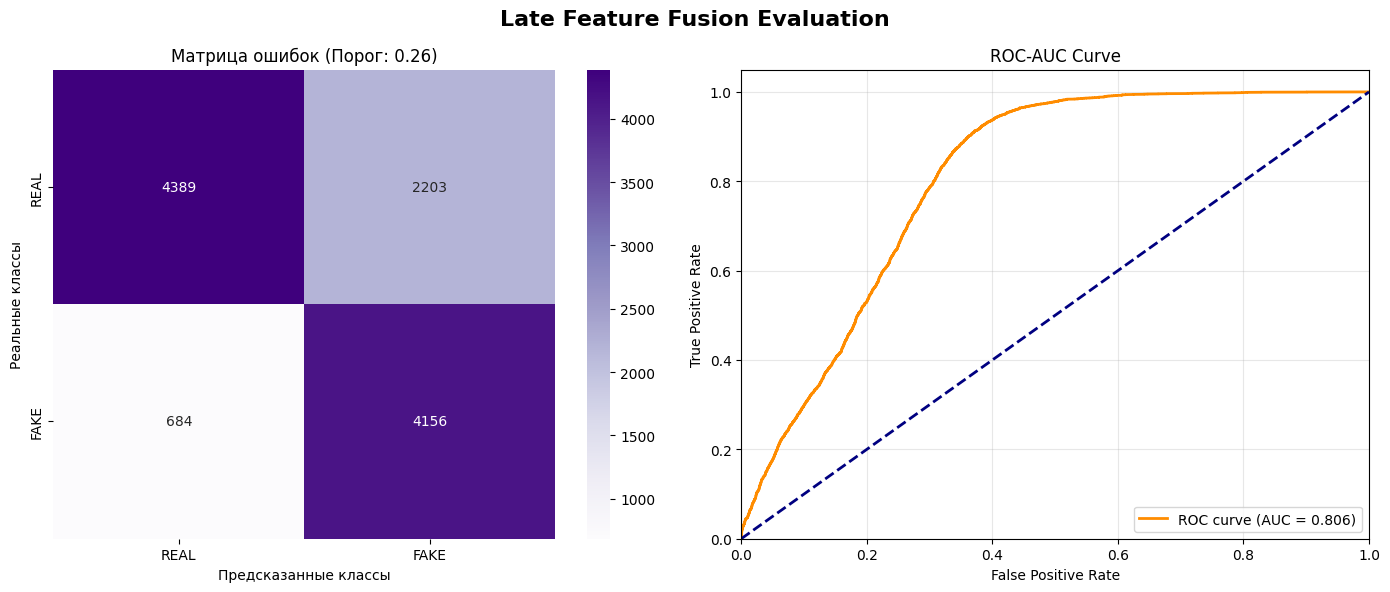

In [ ]:
"""
LATE FEATURE FUSION (RGB + ELA) - PRODUCTION & THESIS VERSION
---------------------------------
Архитектура:
1. Frozen RGB ResNet18 -> 512-d
2. Frozen ELA ResNet18 -> 512-d
3. Concatenation -> 1024-d
4. Trainable MLP Head (No BatchNorm) -> 2 classes

Ключевые исправления:
- Отказ от онлайн-генерации ELA: признаки берутся из оффлайн-датасета (без domain shift).
- Жесткая блокировка BatchNorm: переопределен метод train(), чтобы ветки всегда были в .eval().
- Поиск порога по F1 'macro' для баланса между REAL и FAKE.
- Строгий Source-Aware Split.
"""

import os
import csv
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import transforms, models
from PIL import Image
import numpy as np
import random
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, f1_score
from pathlib import Path

# ==========================================
# 1. ФИКСАЦИЯ СИДОВ (Для строгой научности)
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

print(f"🚀 Запуск Late Feature Fusion на {device}")

# ==========================================
# 2. НАСТРОЙКИ ПУТЕЙ
# ==========================================
ROOT_DIR = Path("/content")

# Указываем раздельные пути для RGB и готового ELA датасетов
RGB_DATASET_DIR = ROOT_DIR / "CASIA_Unified_Randomized_RGB_v2"
ELA_DATASET_DIR = ROOT_DIR / "CASIA_Unified_Randomized_v2"
CSV_LOG_PATH = ELA_DATASET_DIR / "dataset_log.csv"

DRIVE_DIR = Path("/content/drive/MyDrive/Colab Notebooks")
RGB_MODEL_PATH = ROOT_DIR / "model_resnet_rgb_LATEST.pth"
ELA_MODEL_PATH = ROOT_DIR / "model_resnet_ela_sourceaware_v2.pth"

FUSION_OUT_DIR = ROOT_DIR / "artifacts" / "fusion"
FUSION_OUT_DIR.mkdir(parents=True, exist_ok=True)
FUSION_MODEL_SAVE = DRIVE_DIR / "model_fusion_LATEST.pth"

# ==========================================
# 3. ФУНДАМЕНТАЛЬНЫЙ ДАТАСЕТ (ОФФЛАЙН ЧТЕНИЕ)
# ==========================================
class FusionDataset(Dataset):
    def __init__(self, rgb_dir, ela_dir, transform_rgb=None, transform_ela=None):
        self.rgb_dir = rgb_dir
        self.ela_dir = ela_dir
        self.transform_rgb = transform_rgb
        self.transform_ela = transform_ela
        self.samples = []

        for label_name, label_idx in [("REAL", 0), ("FAKE", 1)]:
            rgb_class_dir = os.path.join(self.rgb_dir, label_name)
            ela_class_dir = os.path.join(self.ela_dir, label_name)

            assert os.path.exists(rgb_class_dir), f"Directory not found: {rgb_class_dir}"
            assert os.path.exists(ela_class_dir), f"Directory not found: {ela_class_dir}"

            filenames = sorted(os.listdir(ela_class_dir))

            for filename in filenames:
                if filename.lower().endswith((".png", ".jpg", ".jpeg")):
                    ela_path = os.path.join(ela_class_dir, filename)
                    rgb_path = os.path.join(rgb_class_dir, filename)

                    assert os.path.exists(rgb_path), f"Missing RGB pair for {filename} in {rgb_class_dir}"
                    self.samples.append((rgb_path, ela_path, label_idx, filename))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        rgb_path, ela_path, label, filename = self.samples[idx]

        img_rgb = Image.open(rgb_path).convert("RGB")
        img_ela = Image.open(ela_path).convert("RGB")

        if self.transform_rgb:
            tensor_rgb = self.transform_rgb(img_rgb)
        else:
            tensor_rgb = img_rgb

        if self.transform_ela:
            tensor_ela = self.transform_ela(img_ela)
        else:
            tensor_ela = img_ela

        return tensor_rgb, tensor_ela, label, filename

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# ==========================================
# 4. АРХИТЕКТУРА LATE FUSION (С ЗАЩИТОЙ BATCHNORM)
# ==========================================
class LateFusionModel(nn.Module):
    def __init__(self, rgb_weights, ela_weights):
        super(LateFusionModel, self).__init__()

        # Загружаем RGB ветку
        self.rgb_branch = models.resnet18(weights=None)
        self.rgb_branch.fc = nn.Linear(self.rgb_branch.fc.in_features, 2)
        self.rgb_branch.load_state_dict(torch.load(rgb_weights, map_location=device))
        self.rgb_branch.fc = nn.Identity()

        # Загружаем ELA ветку
        self.ela_branch = models.resnet18(weights=None)
        self.ela_branch.fc = nn.Linear(self.ela_branch.fc.in_features, 2)
        self.ela_branch.load_state_dict(torch.load(ela_weights, map_location=device))
        self.ela_branch.fc = nn.Identity()

        # ГЛУХАЯ ЗАМОРОЗКА БАЗОВЫХ СЕТЕЙ
        for param in self.rgb_branch.parameters(): param.requires_grad = False
        for param in self.ela_branch.parameters(): param.requires_grad = False

        # ОБУЧАЕМАЯ ГОЛОВА (MLP, без BatchNorm)
        self.mlp_head = nn.Sequential(
            nn.Linear(1024, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 2)
        )

    def train(self, mode=True):
        """
        Переопределение метода train() для защиты BatchNorm слоев в замороженных ветках
        от случайного обновления running_mean и running_var.
        """
        super().train(mode)
        # Независимо от общего режима модели, базовые ветки ВСЕГДА остаются в eval
        self.rgb_branch.eval()
        self.ela_branch.eval()
        return self

    def forward(self, x_rgb, x_ela):
        with torch.no_grad():
            emb_rgb = self.rgb_branch(x_rgb)
            emb_ela = self.ela_branch(x_ela)

        fused_features = torch.cat((emb_rgb, emb_ela), dim=1)
        return self.mlp_head(fused_features), emb_rgb, emb_ela, fused_features

# ==========================================
# 5. СТРОГИЙ SOURCE-AWARE СПЛИТ
# ==========================================
print("📁 Чтение логов и сборка Source-Aware датасетов...")

full_train_dataset = FusionDataset(
    rgb_dir=RGB_DATASET_DIR / "train",
    ela_dir=ELA_DATASET_DIR / "train",
    transform_rgb=transform,
    transform_ela=transform
)
test_dataset = FusionDataset(
    rgb_dir=RGB_DATASET_DIR / "test",
    ela_dir=ELA_DATASET_DIR / "test",
    transform_rgb=transform,
    transform_ela=transform
)

file_to_original = {}
with open(CSV_LOG_PATH, encoding="utf-8") as f:
    reader = csv.DictReader(f)
    for row in reader:
        file_to_original[row["filename"]] = row["original_filename"]

unique_originals = sorted({file_to_original[filename] for _, _, _, filename in full_train_dataset.samples})
rng = random.Random(42)
rng.shuffle(unique_originals)

val_count = round(len(unique_originals) * 0.1)
val_originals = set(unique_originals[:val_count])

train_indices, val_indices = [], []
for idx, (_, _, _, filename) in enumerate(full_train_dataset.samples):
    if file_to_original[filename] in val_originals:
        val_indices.append(idx)
    else:
        train_indices.append(idx)

train_subset = Subset(full_train_dataset, train_indices)
val_subset = Subset(full_train_dataset, val_indices)

train_loader = DataLoader(train_subset, batch_size=64, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_subset, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)

print(f"✅ Split завершен. Train: {len(train_subset)}, Val: {len(val_subset)}, Test: {len(test_dataset)}")

# ==========================================
# 6. ИНИЦИАЛИЗАЦИЯ И ОБУЧЕНИЕ
# ==========================================
print("\n⚙️ Инициализация Late Feature Fusion Модели...")
model = LateFusionModel(RGB_MODEL_PATH, ELA_MODEL_PATH).to(device)

optimizer = optim.AdamW(model.mlp_head.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)
criterion = nn.CrossEntropyLoss()

epochs = 15
best_val_loss = float("inf")
patience, no_improve = 4, 0

print("\n🚀 СТАРТ ОБУЧЕНИЯ (Обучается только MLP, бэкенды заморожены)...")
for epoch in range(epochs):
    model.train() # Теперь это безопасно для BatchNorm
    running_loss = 0.0
    for rgb_imgs, ela_imgs, labels, _ in train_loader:
        rgb_imgs, ela_imgs, labels = rgb_imgs.to(device), ela_imgs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs, _, _, _ = model(rgb_imgs, ela_imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for rgb_imgs, ela_imgs, labels, _ in val_loader:
            rgb_imgs, ela_imgs, labels = rgb_imgs.to(device), ela_imgs.to(device), labels.to(device)
            outputs, _, _, _ = model(rgb_imgs, ela_imgs)
            val_loss += criterion(outputs, labels).item()

    val_loss /= len(val_loader)
    scheduler.step(val_loss)

    print(f"Эпоха {epoch+1:02d}/{epochs} | Train Loss: {running_loss/len(train_loader):.4f} | Val Loss: {val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        no_improve = 0
        torch.save(model.state_dict(), FUSION_MODEL_SAVE)
        print("  [+] Сохранена лучшая модель MLP-фьюжена")
    else:
        no_improve += 1
        if no_improve >= patience:
            print(f"🛑 Early stopping на эпохе {epoch+1}")
            break

# ==========================================
# 7. ПОИСК ПОРОГА НА VALIDATION (ПО F1 MACRO)
# ==========================================
print("\n🔍 ПОИСК ПОРОГА НА VALIDATION ВЫБОРКЕ...")
model.load_state_dict(torch.load(FUSION_MODEL_SAVE))
model.eval()

val_labels_roc, val_probs_roc = [], []
with torch.no_grad():
    for rgb_imgs, ela_imgs, labels, _ in val_loader:
        rgb_imgs, ela_imgs = rgb_imgs.to(device), ela_imgs.to(device)
        outputs, _, _, _ = model(rgb_imgs, ela_imgs)
        probs = torch.softmax(outputs, dim=1)[:, 1]

        val_labels_roc.extend(labels.numpy())
        val_probs_roc.extend(probs.cpu().numpy())

fpr_v, tpr_v, thresholds_v = roc_curve(val_labels_roc, val_probs_roc)
# Исправлено: average='macro' для баланса между FAKE и REAL
f1_scores_v = [f1_score(val_labels_roc, [1 if p >= t else 0 for p in val_probs_roc], average='macro') for t in thresholds_v]
best_thresh = thresholds_v[np.argmax(f1_scores_v)]
print(f"✅ Оптимальный порог (Macro F1) найден: {best_thresh:.4f}")

# ==========================================
# 8. ЧЕСТНЫЙ ЭКЗАМЕН И ЛОГИРОВАНИЕ
# ==========================================
print("\n🎯 ЭКЗАМЕН FUSION-МОДЕЛИ НА ИЗОЛИРОВАННОМ ТЕСТЕ...")

test_labels, test_probs, test_filenames = [], [], []
test_logits = []
test_emb_rgb, test_emb_ela, test_emb_fused = [], [], []

with torch.no_grad():
    for rgb_imgs, ela_imgs, labels, filenames in test_loader:
        rgb_imgs, ela_imgs = rgb_imgs.to(device), ela_imgs.to(device)

        outputs, emb_rgb, emb_ela, fused_features = model(rgb_imgs, ela_imgs)
        probs = torch.softmax(outputs, dim=1)[:, 1]

        test_labels.extend(labels.numpy())
        test_probs.extend(probs.cpu().numpy())
        test_logits.extend(outputs.cpu().numpy())
        test_filenames.extend(filenames)

        test_emb_rgb.extend(emb_rgb.cpu().numpy())
        test_emb_ela.extend(emb_ela.cpu().numpy())
        test_emb_fused.extend(fused_features.cpu().numpy())

test_preds = [1 if p >= best_thresh else 0 for p in test_probs]

print("\n" + "="*50)
print(f"📊 ФИНАЛЬНЫЙ ОТЧЕТ: FUSION (Порог: {best_thresh:.4f})")
print("="*50)
print(classification_report(test_labels, test_preds, target_names=['REAL', 'FAKE']))

# --- ЭКСПОРТ МЕТАДАННЫХ (CSV) ---
predictions_csv_path = FUSION_OUT_DIR / "fusion_test_metadata.csv"
df_preds = pd.DataFrame({
    'filename': test_filenames,
    'true_label': test_labels,
    'logit_0': [l[0] for l in test_logits],
    'logit_1': [l[1] for l in test_logits],
    'prob_fake': test_probs,
    'pred_label': test_preds
})
df_preds.to_csv(predictions_csv_path, index=False)
print(f"📄 Метаданные предсказаний сохранены: {predictions_csv_path}")

# --- ЭКСПОРТ NUMPY МАССИВОВ ДЛЯ t-SNE / PCA ---
np.save(FUSION_OUT_DIR / "test_embeddings_rgb_512d.npy", np.array(test_emb_rgb))
np.save(FUSION_OUT_DIR / "test_embeddings_ela_512d.npy", np.array(test_emb_ela))
np.save(FUSION_OUT_DIR / "test_embeddings_fused_1024d.npy", np.array(test_emb_fused))
np.save(FUSION_OUT_DIR / "test_labels.npy", np.array(test_labels))
print(f"💾 Эмбеддинги и метки классов успешно экспортированы в {FUSION_OUT_DIR}!")

# ==========================================
# 9. ВИЗУАЛИЗАЦИЯ (ROC & Confusion Matrix)
# ==========================================
fpr_t, tpr_t, _ = roc_curve(test_labels, test_probs)
roc_auc_val = auc(fpr_t, tpr_t)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Late Feature Fusion Evaluation", fontsize=16, fontweight='bold')

cm = confusion_matrix(test_labels, test_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', xticklabels=['REAL', 'FAKE'], yticklabels=['REAL', 'FAKE'], ax=ax1)
ax1.set_ylabel('Реальные классы')
ax1.set_xlabel('Предсказанные классы')
ax1.set_title(f'Матрица ошибок (Порог: {best_thresh:.2f})')

ax2.plot(fpr_t, tpr_t, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc_val:.3f})')
ax2.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax2.set_xlim([0.0, 1.0])
ax2.set_ylim([0.0, 1.05])
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.set_title('ROC-AUC Curve')
ax2.legend(loc="lower right")
ax2.grid(alpha=0.3)

plot_path = FUSION_OUT_DIR / "thesis_fusion_eval.png"
plt.tight_layout()
plt.savefig(plot_path, dpi=300)
print(f"✅ Графики сохранены: {plot_path}")

🚀 Запуск Final Late Feature Fusion (V2) на cuda
📁 Чтение логов и сборка Source-Aware датасетов (Composite Key)...

📈 ПЕРЕВІРКА НА УТЕЧКУ (DATA LEAKAGE) — Fusion Source-Aware:
Train: 41124 | Val: 4568
Унікальних оригіналів Train: 10281 | Val: 1142
Перетинів оригіналів: 0

✅ Split завершен. Train: 41124, Val: 4568, Test: 11432

⚙️ Инициализация Late Feature Fusion Модели (V2)...

🚀 СТАРТ ОБУЧЕНИЯ (Обучается только MLP, бэкенды заморожены)...
Эпоха 01/15 | Train Loss: 0.3640 | Val Loss: 0.4601
  [+] Сохранена лучшая модель MLP-фьюжена V2
Эпоха 02/15 | Train Loss: 0.3384 | Val Loss: 0.4730
Эпоха 03/15 | Train Loss: 0.3324 | Val Loss: 0.4489
  [+] Сохранена лучшая модель MLP-фьюжена V2
Эпоха 04/15 | Train Loss: 0.3270 | Val Loss: 0.4642
Эпоха 05/15 | Train Loss: 0.3244 | Val Loss: 0.4673
Эпоха 06/15 | Train Loss: 0.3203 | Val Loss: 0.4856
Эпоха 07/15 | Train Loss: 0.3117 | Val Loss: 0.4753
🛑 Early stopping на эпохе 7

🔍 ПОИСК ПОРОГА НА VALIDATION ВЫБОРКЕ...
✅ Оптимальный порог (Macro F1) на

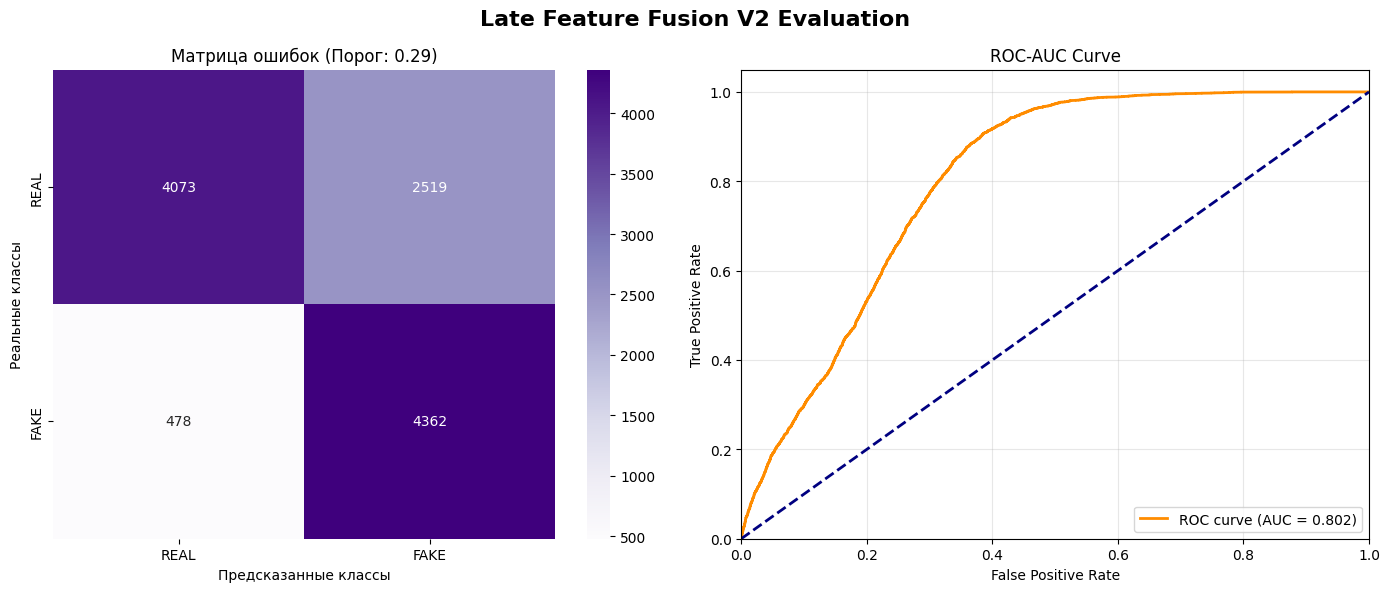

In [6]:
"""
LATE FEATURE FUSION (RGB + ELA) - FINAL THESIS VERSION (V2)
---------------------------------
Использует:
- Чистый RGB Baseline
- Чистый ELA Baseline (Source-Aware V2)

Ключевые исправления в V2:
- Составной ключ (source_dataset, original_filename) для 100% идентичности сплита с ELA.
- Добавлен label_smoothing=0.05 в CrossEntropyLoss для идентичности условий обучения с RGB и ELA.
"""

import os
import csv
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import transforms, models
from PIL import Image
import numpy as np
import random
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, f1_score
from pathlib import Path

# ==========================================
# 1. ФИКСАЦИЯ СИДОВ
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

print(f"🚀 Запуск Final Late Feature Fusion (V2) на {device}")

# ==========================================
# 2. НАСТРОЙКИ ПУТЕЙ
# ==========================================
ROOT_DIR = Path("/content")

RGB_DATASET_DIR = ROOT_DIR / "CASIA_Unified_Randomized_RGB_v2"
ELA_DATASET_DIR = ROOT_DIR / "CASIA_Unified_Randomized_v2"
CSV_LOG_PATH = ELA_DATASET_DIR / "dataset_log.csv"

DRIVE_DIR = Path("/content/drive/MyDrive/Colab Notebooks")

# Используем НОВЫЕ честные веса!
RGB_MODEL_PATH = ROOT_DIR / "model_resnet_rgb_LATEST.pth"
ELA_MODEL_PATH = ROOT_DIR / "model_resnet_ela_sourceaware_v2.pth"

FUSION_OUT_DIR = ROOT_DIR / "artifacts" / "fusion_v2"
FUSION_OUT_DIR.mkdir(parents=True, exist_ok=True)
FUSION_MODEL_SAVE = DRIVE_DIR / "model_fusion_sourceaware_v2.pth"

# ==========================================
# 3. ДАТАСЕТ (ОФФЛАЙН ЧТЕНИЕ)
# ==========================================
class FusionDataset(Dataset):
    def __init__(self, rgb_dir, ela_dir, transform_rgb=None, transform_ela=None):
        self.rgb_dir = rgb_dir
        self.ela_dir = ela_dir
        self.transform_rgb = transform_rgb
        self.transform_ela = transform_ela
        self.samples = []

        for label_name, label_idx in [("REAL", 0), ("FAKE", 1)]:
            rgb_class_dir = os.path.join(self.rgb_dir, label_name)
            ela_class_dir = os.path.join(self.ela_dir, label_name)

            assert os.path.exists(rgb_class_dir), f"Directory not found: {rgb_class_dir}"
            assert os.path.exists(ela_class_dir), f"Directory not found: {ela_class_dir}"

            filenames = sorted(os.listdir(ela_class_dir))

            for filename in filenames:
                if filename.lower().endswith((".png", ".jpg", ".jpeg")):
                    ela_path = os.path.join(ela_class_dir, filename)
                    rgb_path = os.path.join(rgb_class_dir, filename)

                    assert os.path.exists(rgb_path), f"Missing RGB pair for {filename} in {rgb_class_dir}"
                    self.samples.append((rgb_path, ela_path, label_idx, filename))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        rgb_path, ela_path, label, filename = self.samples[idx]

        img_rgb = Image.open(rgb_path).convert("RGB")
        img_ela = Image.open(ela_path).convert("RGB")

        if self.transform_rgb:
            tensor_rgb = self.transform_rgb(img_rgb)
        else:
            tensor_rgb = img_rgb

        if self.transform_ela:
            tensor_ela = self.transform_ela(img_ela)
        else:
            tensor_ela = img_ela

        return tensor_rgb, tensor_ela, label, filename

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# ==========================================
# 4. АРХИТЕКТУРА LATE FUSION (С ЗАЩИТОЙ BATCHNORM)
# ==========================================
class LateFusionModel(nn.Module):
    def __init__(self, rgb_weights, ela_weights):
        super(LateFusionModel, self).__init__()

        self.rgb_branch = models.resnet18(weights=None)
        self.rgb_branch.fc = nn.Linear(self.rgb_branch.fc.in_features, 2)
        self.rgb_branch.load_state_dict(torch.load(rgb_weights, map_location=device))
        self.rgb_branch.fc = nn.Identity()

        self.ela_branch = models.resnet18(weights=None)
        self.ela_branch.fc = nn.Linear(self.ela_branch.fc.in_features, 2)
        self.ela_branch.load_state_dict(torch.load(ela_weights, map_location=device))
        self.ela_branch.fc = nn.Identity()

        for param in self.rgb_branch.parameters(): param.requires_grad = False
        for param in self.ela_branch.parameters(): param.requires_grad = False

        self.mlp_head = nn.Sequential(
            nn.Linear(1024, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 2)
        )

    def train(self, mode=True):
        super().train(mode)
        self.rgb_branch.eval()
        self.ela_branch.eval()
        return self

    def forward(self, x_rgb, x_ela):
        with torch.no_grad():
            emb_rgb = self.rgb_branch(x_rgb)
            emb_ela = self.ela_branch(x_ela)

        fused_features = torch.cat((emb_rgb, emb_ela), dim=1)
        return self.mlp_head(fused_features), emb_rgb, emb_ela, fused_features

# ==========================================
# 5. СТРОГИЙ SOURCE-AWARE СПЛИТ (Составной ключ)
# ==========================================
print("📁 Чтение логов и сборка Source-Aware датасетов (Composite Key)...")

full_train_dataset = FusionDataset(
    rgb_dir=RGB_DATASET_DIR / "train",
    ela_dir=ELA_DATASET_DIR / "train",
    transform_rgb=transform,
    transform_ela=transform
)
test_dataset = FusionDataset(
    rgb_dir=RGB_DATASET_DIR / "test",
    ela_dir=ELA_DATASET_DIR / "test",
    transform_rgb=transform,
    transform_ela=transform
)

file_to_source = {}
with open(CSV_LOG_PATH, encoding="utf-8") as f:
    reader = csv.DictReader(f)
    for row in reader:
        file_to_source[row["filename"]] = (
            row["source_dataset"],
            row["original_filename"]
        )

unique_sources = sorted({file_to_source[filename] for _, _, _, filename in full_train_dataset.samples})
rng = random.Random(42)
rng.shuffle(unique_sources)

val_count = round(len(unique_sources) * 0.1)
val_sources = set(unique_sources[:val_count])

train_indices, val_indices = [], []
for idx, (_, _, _, filename) in enumerate(full_train_dataset.samples):
    source_key = file_to_source[filename]
    if source_key in val_sources:
        val_indices.append(idx)
    else:
        train_indices.append(idx)

train_subset = Subset(full_train_dataset, train_indices)
val_subset = Subset(full_train_dataset, val_indices)

# Проверка на утечку (идентично скрипту ELA)
train_sources_check = {file_to_source[full_train_dataset.samples[i][3]] for i in train_indices}
val_sources_check = {file_to_source[full_train_dataset.samples[i][3]] for i in val_indices}
intersection = train_sources_check & val_sources_check

print("\n" + "="*50)
print("📈 ПЕРЕВІРКА НА УТЕЧКУ (DATA LEAKAGE) — Fusion Source-Aware:")
print(f"Train: {len(train_indices)} | Val: {len(val_indices)}")
print(f"Унікальних оригіналів Train: {len(train_sources_check)} | Val: {len(val_sources_check)}")
print(f"Перетинів оригіналів: {len(intersection)}")
print("="*50 + "\n")

assert len(intersection) == 0, "Обнаружена утечка исходников!"

train_loader = DataLoader(train_subset, batch_size=64, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_subset, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)

print(f"✅ Split завершен. Train: {len(train_subset)}, Val: {len(val_subset)}, Test: {len(test_dataset)}")

# ==========================================
# 6. ИНИЦИАЛИЗАЦИЯ И ОБУЧЕНИЕ
# ==========================================
print("\n⚙️ Инициализация Late Feature Fusion Модели (V2)...")
model = LateFusionModel(RGB_MODEL_PATH, ELA_MODEL_PATH).to(device)

optimizer = optim.AdamW(model.mlp_head.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

# Добавлен label_smoothing=0.05 для соответствия RGB и ELA
criterion = nn.CrossEntropyLoss(label_smoothing=0.05)

epochs = 15
best_val_loss = float("inf")
patience, no_improve = 4, 0

print("\n🚀 СТАРТ ОБУЧЕНИЯ (Обучается только MLP, бэкенды заморожены)...")
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for rgb_imgs, ela_imgs, labels, _ in train_loader:
        rgb_imgs, ela_imgs, labels = rgb_imgs.to(device), ela_imgs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs, _, _, _ = model(rgb_imgs, ela_imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for rgb_imgs, ela_imgs, labels, _ in val_loader:
            rgb_imgs, ela_imgs, labels = rgb_imgs.to(device), ela_imgs.to(device), labels.to(device)
            outputs, _, _, _ = model(rgb_imgs, ela_imgs)
            val_loss += criterion(outputs, labels).item()

    val_loss /= len(val_loader)
    scheduler.step(val_loss)

    print(f"Эпоха {epoch+1:02d}/{epochs} | Train Loss: {running_loss/len(train_loader):.4f} | Val Loss: {val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        no_improve = 0
        torch.save(model.state_dict(), FUSION_MODEL_SAVE)
        print("  [+] Сохранена лучшая модель MLP-фьюжена V2")
    else:
        no_improve += 1
        if no_improve >= patience:
            print(f"🛑 Early stopping на эпохе {epoch+1}")
            break

# ==========================================
# 7. ПОИСК ПОРОГА НА VALIDATION (ПО F1 MACRO)
# ==========================================
print("\n🔍 ПОИСК ПОРОГА НА VALIDATION ВЫБОРКЕ...")
model.load_state_dict(torch.load(FUSION_MODEL_SAVE, map_location=device))
model.eval()

val_labels_roc, val_probs_roc = [], []
with torch.no_grad():
    for rgb_imgs, ela_imgs, labels, _ in val_loader:
        rgb_imgs, ela_imgs = rgb_imgs.to(device), ela_imgs.to(device)
        outputs, _, _, _ = model(rgb_imgs, ela_imgs)
        probs = torch.softmax(outputs, dim=1)[:, 1]

        val_labels_roc.extend(labels.numpy())
        val_probs_roc.extend(probs.cpu().numpy())

fpr_v, tpr_v, thresholds_v = roc_curve(val_labels_roc, val_probs_roc)
f1_scores_v = [f1_score(val_labels_roc, [1 if p >= t else 0 for p in val_probs_roc], average='macro') for t in thresholds_v]
best_thresh = thresholds_v[np.argmax(f1_scores_v)]
print(f"✅ Оптимальный порог (Macro F1) найден: {best_thresh:.4f}")

# ==========================================
# 8. ЧЕСТНЫЙ ЭКЗАМЕН И ЛОГИРОВАНИЕ
# ==========================================
print("\n🎯 ЭКЗАМЕН FUSION-МОДЕЛИ V2 НА ИЗОЛИРОВАННОМ ТЕСТЕ...")

test_labels, test_probs, test_filenames = [], [], []
test_logits = []
test_emb_rgb, test_emb_ela, test_emb_fused = [], [], []

with torch.no_grad():
    for rgb_imgs, ela_imgs, labels, filenames in test_loader:
        rgb_imgs, ela_imgs = rgb_imgs.to(device), ela_imgs.to(device)

        outputs, emb_rgb, emb_ela, fused_features = model(rgb_imgs, ela_imgs)
        probs = torch.softmax(outputs, dim=1)[:, 1]

        test_labels.extend(labels.numpy())
        test_probs.extend(probs.cpu().numpy())
        test_logits.extend(outputs.cpu().numpy())
        test_filenames.extend(filenames)

        test_emb_rgb.extend(emb_rgb.cpu().numpy())
        test_emb_ela.extend(emb_ela.cpu().numpy())
        test_emb_fused.extend(fused_features.cpu().numpy())

test_preds = [1 if p >= best_thresh else 0 for p in test_probs]

print("\n" + "="*50)
print(f"📊 ФИНАЛЬНЫЙ ОТЧЕТ: FUSION V2 (Порог: {best_thresh:.4f})")
print("="*50)
print(classification_report(test_labels, test_preds, target_names=['REAL', 'FAKE']))

# --- ЭКСПОРТ ---
predictions_csv_path = FUSION_OUT_DIR / "fusion_v2_test_metadata.csv"
df_preds = pd.DataFrame({
    'filename': test_filenames,
    'true_label': test_labels,
    'logit_0': [l[0] for l in test_logits],
    'logit_1': [l[1] for l in test_logits],
    'prob_fake': test_probs,
    'pred_label': test_preds
})
df_preds.to_csv(predictions_csv_path, index=False)
print(f"📄 Метаданные предсказаний сохранены: {predictions_csv_path}")

np.save(FUSION_OUT_DIR / "test_embeddings_rgb_512d.npy", np.array(test_emb_rgb))
np.save(FUSION_OUT_DIR / "test_embeddings_ela_512d.npy", np.array(test_emb_ela))
np.save(FUSION_OUT_DIR / "test_embeddings_fused_1024d.npy", np.array(test_emb_fused))
np.save(FUSION_OUT_DIR / "test_labels.npy", np.array(test_labels))
print(f"💾 Эмбеддинги и метки классов успешно экспортированы в {FUSION_OUT_DIR}!")

# ==========================================
# 9. ВИЗУАЛИЗАЦИЯ
# ==========================================
fpr_t, tpr_t, _ = roc_curve(test_labels, test_probs)
roc_auc_val = auc(fpr_t, tpr_t)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Late Feature Fusion V2 Evaluation", fontsize=16, fontweight='bold')

cm = confusion_matrix(test_labels, test_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', xticklabels=['REAL', 'FAKE'], yticklabels=['REAL', 'FAKE'], ax=ax1)
ax1.set_ylabel('Реальные классы')
ax1.set_xlabel('Предсказанные классы')
ax1.set_title(f'Матрица ошибок (Порог: {best_thresh:.2f})')

ax2.plot(fpr_t, tpr_t, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc_val:.3f})')
ax2.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax2.set_xlim([0.0, 1.0])
ax2.set_ylim([0.0, 1.05])
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.set_title('ROC-AUC Curve')
ax2.legend(loc="lower right")
ax2.grid(alpha=0.3)

plot_path = FUSION_OUT_DIR / "thesis_fusion_v2_eval.png"
plt.tight_layout()
plt.savefig(plot_path, dpi=300)
print(f"✅ Графики сохранены: {plot_path}")